# Сравнение детекторов аномалий траектории

Наблюдение — точка `(time, lat, lon)`. В `CalculateMetrics` метка `0` — аномалия (`status == anomaly`), метка `1` — штатная точка (`move` и `stand`).

Обучение forecasting- и reconstruction-методов идёт только по штатным точкам обучающей выборки, без её последних 20 000 точек: этот хвост нужен, чтобы выбрать порог. DBSCAN, LOF, Isolation Forest, Hampel, фильтр Калмана, particle filter, Robust PCA и MPCT обучающую выборку для подгонки модели не используют; порог или `eps`, если он есть, всё равно выбирается по хвосту обучения. Метрики считаются только по тестовым 100 000 точкам. Для PR-AUC в `calculate_all_metrics` передаётся anomaly score: большее значение — более аномальная точка.


In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import logsumexp
from scipy.stats import chi2
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.svm import OneClassSVM
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

SEED = 7
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")
torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))

START_IND = 200_000
END_IND = 700_000
TEST_SIZE = 100_000
VAL_SIZE = 20_000
PLOT_TAIL = 50_000
EARTH_RADIUS_M = 6_371_000.0
N_EPOCHS = 6
N_WINDOWS = 8_000
N_PARTICLES = 32


def find_root() -> Path:
    """Корень репозитория: рядом лежат data/2.csv и пакет app."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "2.csv").exists() and (candidate / "app").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с data/2.csv")


path_root = find_root()
path = path_root / "data" / "2.csv"
sys.path.insert(0, str(path_root))

from app.metrics.calculate_metrics import CalculateMetrics
from app.metrics.plot_sample_track import plot_sample_track

print(f"Корень: {path_root}")
print(f"Файл: {path}")
print(f"PyTorch {torch.__version__}, потоков {torch.get_num_threads()}")


Корень: /home/ubuntu/PycharmProjects/statistical_researchs
Файл: /home/ubuntu/PycharmProjects/statistical_researchs/data/2.csv
PyTorch 2.14.1+cpu, потоков 8


# Данные

Сначала из `data/2.csv` берётся фрагмент по индексам строк, как в исходном примере: `START_IND = 200_000`, `END_IND = 700_000`, срез `raw.iloc[START_IND:END_IND]` (строки с индексом 200_000 по 699_999).

Из фрагмента убираются `sat` и `is_water` (в метриках и моделях не используются). Строки с пустой широтой или долготой и строки, где широта или долгота равна 0, удаляются. Последние 100 000 оставшихся точек — тест, всё предыдущее — обучение. Внутри обучения последние 20 000 точек — выбор порога.


In [2]:
raw_full = pd.read_csv(path)
raw = raw_full.iloc[START_IND:END_IND].reset_index(drop=True)

frame = raw.drop(columns=["sat", "is_water"]).copy()
frame["lat"] = pd.to_numeric(frame["lat"], errors="coerce")
frame["lon"] = pd.to_numeric(frame["lon"], errors="coerce")
keep = frame["lat"].notna() & frame["lon"].notna() & (frame["lat"] != 0.0) & (frame["lon"] != 0.0)
frame = frame.loc[keep].reset_index(drop=True)
order = np.argsort(pd.to_datetime(frame["time"]).to_numpy(), kind="mergesort")
frame = frame.iloc[order].reset_index(drop=True)

if len(frame) <= TEST_SIZE + VAL_SIZE:
    raise RuntimeError(f"После очистки осталось {len(frame)} строк, этого мало для заданного разбиения.")

test_frame = frame.iloc[-TEST_SIZE:].reset_index(drop=True)
train_frame = frame.iloc[:-TEST_SIZE].reset_index(drop=True)
fit_frame = train_frame.iloc[:-VAL_SIZE].reset_index(drop=True)
val_frame = train_frame.iloc[-VAL_SIZE:].reset_index(drop=True)


def nfmt(value):
    return f"{int(value):,}".replace(",", " ")


def make_pack(data):
    """Собирает одну выборку: время в секундах и бинарная аномалия."""
    stamp = pd.to_datetime(data["time"])
    anomaly = data["status"].to_numpy() == "anomaly"
    return {
        "time": stamp.to_numpy(),
        "t": stamp.to_numpy().astype("datetime64[ns]").astype(np.int64) / 1e9,
        "lat": data["lat"].to_numpy(dtype=float),
        "lon": data["lon"].to_numpy(dtype=float),
        "anom": anomaly,
        "valid": ~anomaly,
    }


def describe(name, pack):
    print(
        f"{name:<16} {nfmt(len(pack['anom'])):>10} точек   "
        f"аномалий {pack['anom'].mean():6.1%}   штатных {pack['valid'].mean():6.1%}"
    )


fit = make_pack(fit_frame)
val = make_pack(val_frame)
test = make_pack(test_frame)
print(
    f"Файл целиком: {nfmt(len(raw_full))} строк, "
    f"фрагмент [{START_IND}:{END_IND}): {nfmt(len(raw))} строк, "
    f"после очистки координат: {nfmt(len(frame))}"
)
print("Признаки моделей: time, lat, lon. Разметка: status.")
describe("Обучение моделей", fit)
describe("Выбор порога", val)
describe("Тест", test)


Файл целиком: 885 152 строк, фрагмент [200000:700000): 500 000 строк, после очистки координат: 245 589
Признаки моделей: time, lat, lon. Разметка: status.
Обучение моделей    125 589 точек   аномалий  39.5%   штатных  60.5%
Выбор порога         20 000 точек   аномалий 100.0%   штатных   0.0%
Тест                100 000 точек   аномалий  24.3%   штатных  75.7%


# Признаки, порог и вывод метрик

Скорость, ускорение и поворот считаются по соседним точкам. Проекция — равноугольная в метрах относительно медианы штатных точек обучения.

Порог `tau` выбирается по хвосту обучения: перебираются квантили score, берётся максимум F1, где положительный класс — аномалия. На тесте пара `(prediction, ground truth)` собирается как `(время, долгота, широта, метка)` и передаётся в `CalculateMetrics.calculate_all_metrics`. Метка `0` — аномалия. Непрерывный score, если он есть у метода, идёт в PR-AUC.

После метрик каждой модели `plot_sample_track` рисует две карты по последним 50 000 точкам теста: слева ground truth, справа разметка модели.


In [3]:
def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def haversine_m(lat1, lon1, lat2, lon2):
    """Геодезическое расстояние на сфере, в метрах."""
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    dlat = lat2 - lat1
    dlon = np.radians(np.asarray(lon2, dtype=float) - np.asarray(lon1, dtype=float))
    dlon = (dlon + np.pi) % (2.0 * np.pi) - np.pi
    step = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * EARTH_RADIUS_M * np.arcsin(np.sqrt(np.clip(step, 0.0, 1.0)))


def bearing(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    east = np.sin(dlon) * np.cos(lat2)
    north = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return np.arctan2(east, north)


def project_m(lat, lon, lat0, lon0):
    east = np.radians(lon - lon0) * np.cos(np.radians(lat0)) * EARTH_RADIUS_M
    north = np.radians(lat - lat0) * EARTH_RADIUS_M
    return np.column_stack([east, north])


def motion_features(lat, lon, t_sec):
    """Скорость, ускорение, поворот курса и шаг в локальных метрах. У первой точки нули."""
    count = len(lat)
    dt = np.ones(count)
    dist = np.zeros(count)
    speed = np.zeros(count)
    acc = np.zeros(count)
    dpsi = np.zeros(count)
    dx = np.zeros(count)
    dy = np.zeros(count)
    if count < 2:
        return dt, dist, speed, acc, dpsi, dx, dy
    dt[1:] = np.diff(t_sec)
    dist[1:] = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])
    speed[1:] = dist[1:] / np.clip(dt[1:], 1.0, None)
    acc[1:] = np.diff(speed) / np.clip(dt[1:], 1.0, None)
    heading = np.zeros(count)
    heading[1:] = bearing(lat[:-1], lon[:-1], lat[1:], lon[1:])
    if count > 2:
        dpsi[2:] = wrap_angle(np.diff(heading[1:]))
    mean_lat = (lat[1:] + lat[:-1]) / 2.0
    dx[1:] = np.radians(lon[1:] - lon[:-1]) * np.cos(np.radians(mean_lat)) * EARTH_RADIUS_M
    dy[1:] = np.radians(lat[1:] - lat[:-1]) * EARTH_RADIUS_M
    return dt, dist, speed, acc, dpsi, dx, dy


def add_motion(pack):
    dt, dist, speed, acc, dpsi, dx, dy = motion_features(pack["lat"], pack["lon"], pack["t"])
    pack.update(dt=dt, dist=dist, speed=speed, acc=acc, dpsi=dpsi, dx=dx, dy=dy)
    return pack


for pack in (fit, val, test):
    add_motion(pack)

origin_lat = float(np.median(fit["lat"][fit["valid"]]))
origin_lon = float(np.median(fit["lon"][fit["valid"]]))
for pack in (fit, val, test):
    pack["xy"] = project_m(pack["lat"], pack["lon"], origin_lat, origin_lon)

normal_obs = np.column_stack([fit["speed"][fit["valid"]], fit["acc"][fit["valid"]], fit["dpsi"][fit["valid"]]])
obs_median = np.median(normal_obs, axis=0)
obs_mad = np.median(np.abs(normal_obs - obs_median), axis=0)
obs_mad = np.where(obs_mad < 1e-6, 1.0, obs_mad) * 1.4826


def kinematic_matrix(pack, sl=None):
    """(скорость, ускорение, поворот), нормированные по штатным точкам обучения."""
    raw_obs = np.column_stack([pack["speed"], pack["acc"], pack["dpsi"]])
    if sl is not None:
        raw_obs = raw_obs[sl]
    return np.clip((raw_obs - obs_median) / obs_mad, -25.0, 25.0)


def robust_params(matrix):
    center = np.median(matrix, axis=0)
    scale = np.subtract(*np.percentile(matrix, [75, 25], axis=0))
    scale = np.where(scale < 1e-6, 1.0, scale)
    return center, scale


def apply_robust(matrix, center, scale):
    return (matrix - center) / scale


def anomaly_f1(is_anomaly, predicted):
    true_positive = np.count_nonzero(is_anomaly & predicted)
    false_positive = np.count_nonzero(~is_anomaly & predicted)
    false_negative = np.count_nonzero(is_anomaly & ~predicted)
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    if precision + recall == 0.0:
        return 0.0
    return 2.0 * precision * recall / (precision + recall)


def remember_val_f1(value):
    """Запоминает F1 порога, чтобы сводная таблица могла показать его рядом с тестом."""
    global LAST_VAL_F1
    LAST_VAL_F1 = float(value)


def select_threshold(scores, is_anomaly, extra=()):
    """Ищет tau по квантилям. Большой score — более аномальная точка.

    Если лучший F1 не лучше отметки «все точки аномальные», классы на хвосте обучения
    не разделяются. Тогда порог ставится на 99.5-й перцентиль score штатных точек.
    """
    scores = np.nan_to_num(np.asarray(scores, dtype=float), nan=0.0, posinf=1e12, neginf=0.0)
    is_anomaly = np.asarray(is_anomaly, dtype=bool)
    quantiles = np.quantile(scores, np.linspace(0.01, 0.995, 180))
    extras = np.atleast_1d(np.asarray(extra, dtype=float))
    candidates = np.unique(np.concatenate([quantiles, extras])) if extras.size else quantiles
    best_tau, best_f1 = float(candidates[0]), -1.0
    for tau in candidates:
        quality = anomaly_f1(is_anomaly, scores > tau)
        if quality > best_f1:
            best_tau, best_f1 = float(tau), float(quality)
    trivial = anomaly_f1(is_anomaly, np.ones(len(scores), dtype=bool))
    normal = scores[~is_anomaly]
    anomalous = scores[is_anomaly]
    if len(normal) and len(anomalous):
        print(
            f"  медиана score: штатные {np.median(normal):.4g}, аномалии {np.median(anomalous):.4g}; "
            f"F1 константы «всё аномалия» {trivial:.3f}"
        )
    if best_f1 < trivial + 0.03 and len(normal):
        best_tau = float(np.quantile(normal, 0.995))
        best_f1 = anomaly_f1(is_anomaly, scores > best_tau)
        print(f"  разделение слабое, порог = 99.5% штатных score: {best_tau:.4g}, F1 {best_f1:.3f}")
    remember_val_f1(best_f1)
    return best_tau, best_f1


def series_pair(predicted_anomaly):
    """Собирает prediction и ground truth для CalculateMetrics.

    Порядок кортежа — (время, долгота, широта, метка). Метка 0 — аномалия.
    """
    predicted_anomaly = np.asarray(predicted_anomaly, dtype=bool)
    truth = np.where(test["anom"], 0.0, 1.0)
    predicted = np.where(predicted_anomaly, 0.0, 1.0)
    ground_truth = (test["time"], test["lon"], test["lat"], truth)
    prediction = (test["time"], test["lon"].copy(), test["lat"].copy(), predicted)
    return prediction, ground_truth


def official_metrics(predicted_anomaly, anomaly_scores=None):
    """Считает метрики CalculateMetrics на тестовой выборке."""
    prediction, ground_truth = series_pair(predicted_anomaly)
    scores = None if anomaly_scores is None else np.asarray(anomaly_scores, dtype=float)
    return CalculateMetrics.calculate_all_metrics(prediction, ground_truth, scores)


RESULTS = []
LAST_VAL_F1 = float("nan")
RATE_FIELDS = [
    ("point_precision", "Point precision"),
    ("point_recall", "Point recall"),
    ("point_f1", "Point F1"),
    ("pr_auc", "PR-AUC"),
    ("affiliation_precision", "Affiliation precision"),
    ("affiliation_recall", "Affiliation recall"),
    ("affiliation_f1", "Affiliation F1"),
]
LIST_FIELDS = RATE_FIELDS + [
    ("detection_delay_median", "Delay median, с"),
    ("detection_delay_mean", "Delay mean, с"),
    ("detection_delay_p95", "Delay p95, с"),
    ("detection_delay_n_events", "Events"),
    ("detection_delay_n_detected", "Detected"),
    ("detection_delay_n_undetected", "Undetected"),
    ("geodesic_rmse", "Geodesic RMSE, м"),
    ("hausdorff_distance", "Hausdorff, м"),
    ("distance_loss", "Distance loss, м"),
    ("distance_loss_ratio", "Distance loss ratio"),
]
COUNT_KEYS = {
    "detection_delay_n_events",
    "detection_delay_n_detected",
    "detection_delay_n_undetected",
}


def format_metric(key, value):
    if value is None or not np.isfinite(value):
        return f"{'—':>14}"
    if key in COUNT_KEYS:
        return f"{nfmt(int(round(value))):>14}"
    if key in {name for name, _ in RATE_FIELDS} or key == "distance_loss_ratio":
        return f"{value:14.4f}"
    return f"{value:14.2f}"


def plot_metric_strip(name, metrics):
    labels = [label for _, label in RATE_FIELDS]
    values = []
    for key, _ in RATE_FIELDS:
        value = metrics[key]
        values.append(np.nan if not np.isfinite(value) else float(value))
    fig, ax = plt.subplots(figsize=(11.2, 1.45))
    image = np.ma.masked_invalid(np.asarray(values, dtype=float)[None, :])
    heat = ax.imshow(image, cmap="YlOrRd", vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_yticks([0])
    ax.set_yticklabels([name])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right")
    for index, value in enumerate(values):
        text = "—" if not np.isfinite(value) else f"{value:.3f}"
        ax.text(index, 0, text, ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(heat, ax=ax, fraction=0.02, pad=0.02)
    fig.tight_layout()
    try:
        from IPython import get_ipython

        interactive = get_ipython() is not None
    except Exception:
        interactive = False
    if interactive:
        plt.show()
    else:
        plt.close(fig)


def slice_series(series, tail):
    """Берёт хвост ряда (время, долгота, широта, метка) для карты."""
    time, lon, lat, label = series
    return time[-tail:], lon[-tail:], lat[-tail:], label[-tail:]


def plot_classification_map(name, predicted_anomaly):
    """Карта ground truth и разметки модели по последним PLOT_TAIL точкам теста."""
    tail = min(PLOT_TAIL, len(predicted_anomaly))
    prediction, ground_truth = series_pair(predicted_anomaly)
    prediction = slice_series(prediction, tail)
    ground_truth = slice_series(ground_truth, tail)
    print(f"  Карта классификации: последние {nfmt(tail)} точек теста")
    plot_sample_track(
        prediction,
        ground_truth,
        title=f"{name}: последние {nfmt(tail)} точек теста",
        figsize=(22.0, 11.0),
        annotate=False,
    )


def show_result(name, predicted_anomaly, elapsed, note, anomaly_scores=None):
    """Печатает список метрик CalculateMetrics, рисует полоску, карту и запоминает строку сводки."""
    global RESULTS, LAST_VAL_F1
    predicted_anomaly = np.asarray(predicted_anomaly, dtype=bool)
    if predicted_anomaly.shape != test["anom"].shape:
        raise ValueError(f"{name}: длина маски {predicted_anomaly.shape[0]} вместо {test['anom'].shape[0]}")
    if anomaly_scores is not None and len(anomaly_scores) != len(predicted_anomaly):
        raise ValueError(f"{name}: длина score {len(anomaly_scores)} вместо {len(predicted_anomaly)}")
    metrics = official_metrics(predicted_anomaly, anomaly_scores)
    print("=" * 72)
    print(name)
    if note:
        print(note)
    print(f"  Помечено аномалиями на тесте: {predicted_anomaly.mean():.1%}   время {elapsed:.1f} с")
    print("  CalculateMetrics, положительный класс — аномалия (метка 0)")
    for key, label in LIST_FIELDS:
        print(f"    {label:<28} {format_metric(key, metrics[key]).strip():>14}")
    plot_metric_strip(name, metrics)
    plot_classification_map(name, predicted_anomaly)
    row = {"Метод": name, "Время, с": elapsed, "F1 хвоста": LAST_VAL_F1}
    for key, _ in LIST_FIELDS:
        row[key] = metrics[key]
    RESULTS = [item for item in RESULTS if item["Метод"] != name]
    RESULTS.append(row)
    LAST_VAL_F1 = float("nan")
    return metrics


def window_starts(pack, length, max_dt, max_dist, require_normal):
    """Индексы окон, которые не пересекают большой разрыв по времени или дистанции."""
    count = len(pack["lat"])
    if count < length:
        return np.empty(0, dtype=int)
    good = np.ones(count, dtype=bool)
    if require_normal:
        good &= pack["valid"]
    step_ok = np.ones(count, dtype=bool)
    step_ok[1:] = (pack["dt"][1:] <= max_dt) & (pack["dist"][1:] <= max_dist)
    good_cum = np.cumsum(good.astype(np.int32))
    step_cum = np.cumsum(step_ok.astype(np.int32))
    starts = np.arange(count - length + 1)
    good_sum = good_cum[starts + length - 1] - np.where(starts > 0, good_cum[starts - 1], 0)
    step_sum = step_cum[starts + length - 1] - step_cum[starts]
    return starts[(good_sum == length) & (step_sum == length - 1)]


def take_starts(starts, limit):
    if len(starts) <= limit:
        return starts
    picked = rng.choice(len(starts), size=limit, replace=False)
    return np.sort(starts[picked])


def scatter_max(count, starts, values, length):
    """Раскладывает оконные score по точкам, в пересечениях оставляет максимум."""
    scores = np.full(count, -np.inf)
    index = starts[:, None] + np.arange(length)[None, :]
    if np.ndim(values) == 1:
        payload = np.repeat(values, length)
    else:
        payload = np.asarray(values, dtype=float).ravel()
    np.maximum.at(scores, index.ravel(), payload)
    scores[~np.isfinite(scores)] = 0.0
    return scores


def train_torch(model, array, loss_fn, epochs, lr=1e-3, batch_size=256):
    model.to(DEVICE)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(np.ascontiguousarray(array))), batch_size=batch_size, shuffle=True
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total, seen = 0.0, 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model, batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += float(loss.detach()) * len(batch)
            seen += len(batch)
        print(f"    эпоха {epoch + 1}/{epochs}, loss {total / max(seen, 1):.5f}")
    model.eval()
    return model


def batched_numpy(model, array, forward, batch_size=512):
    model.eval()
    pieces = []
    with torch.no_grad():
        for start in range(0, len(array), batch_size):
            batch = torch.from_numpy(np.ascontiguousarray(array[start : start + batch_size])).to(DEVICE)
            pieces.append(forward(model, batch).detach().cpu().numpy())
    return np.concatenate(pieces, axis=0)


print(f"Начало локальной проекции: lat {origin_lat:.4f}, lon {origin_lon:.4f}")


Начало локальной проекции: lat 47.8144, lon 42.8565


# Опорные разметки

Две постоянные маски задают края шкалы accuracy на этом тесте: ноль, если все точки объявлены штатными, и единица, если все объявлены аномальными.


Всегда штатная
Каждая тестовая точка помечена штатной.
  Помечено аномалиями на тесте: 0.0%   время 0.0 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                           —
    Point recall                         0.0000
    Point F1                             0.0000
    PR-AUC                                    —
    Affiliation precision                     —
    Affiliation recall                   0.0000
    Affiliation F1                            —
    Delay median, с                           —
    Delay mean, с                             —
    Delay p95, с                              —
    Events                                   51
    Detected                                  0
    Undetected                               51
    Geodesic RMSE, м                  309045.96
    Hausdorff, м                    13057641.03
    Distance loss, м               186265241.06
    Distance loss ratio                  9.9346


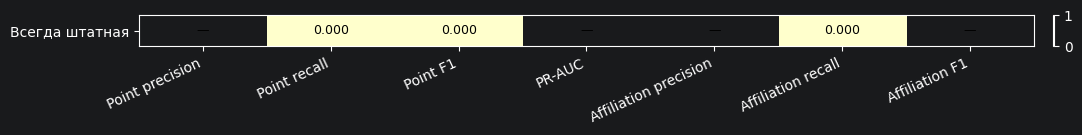

  Карта классификации: последние 50 000 точек теста


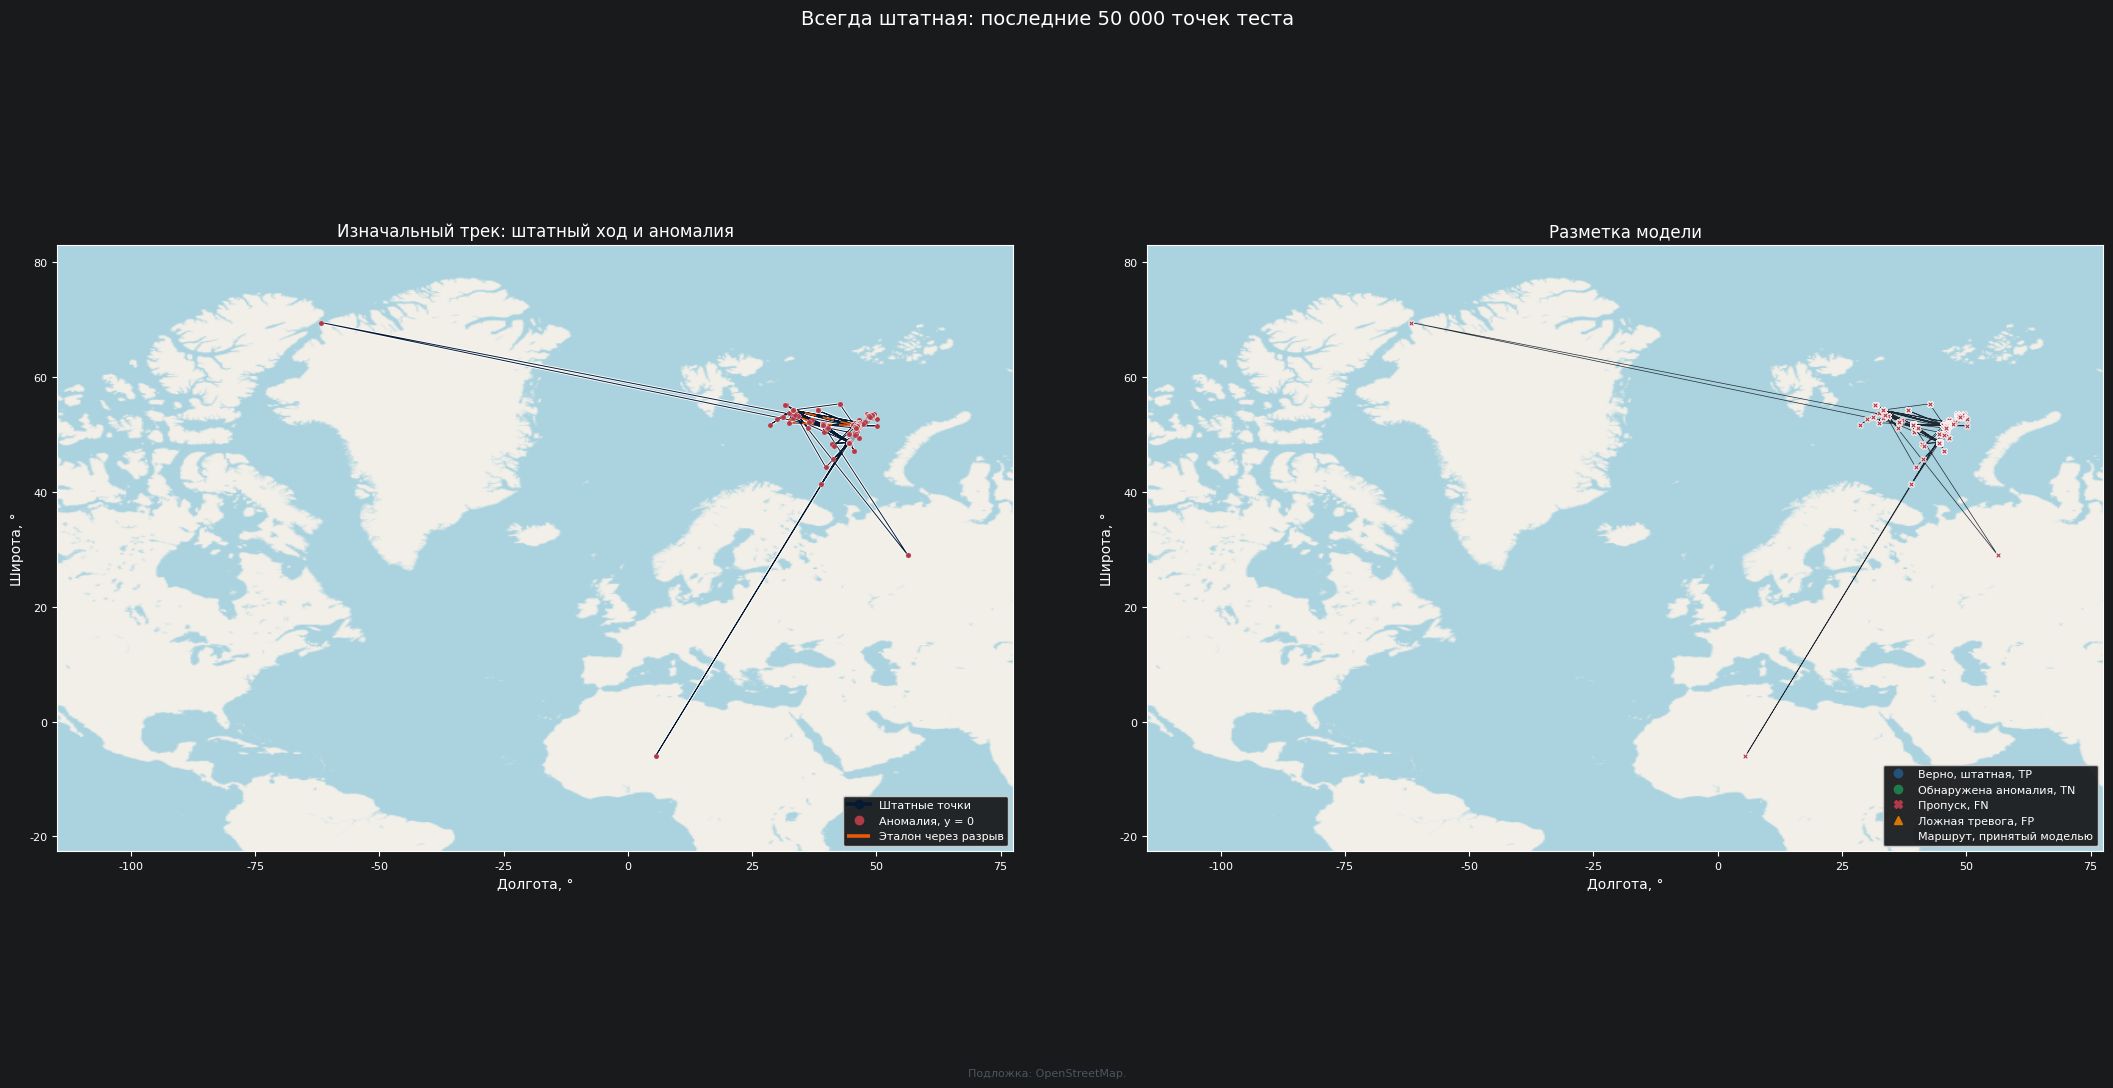

Всегда аномалия
Каждая тестовая точка помечена аномальной.
  Помечено аномалиями на тесте: 100.0%   время 0.0 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2429
    Point recall                         1.0000
    Point F1                             0.3909
    PR-AUC                                    —
    Affiliation precision                0.6682
    Affiliation recall                   1.0000
    Affiliation F1                       0.8011
    Delay median, с                        0.00
    Delay mean, с                          0.00
    Delay p95, с                           0.00
    Events                                   51
    Detected                                 51
    Undetected                                0
    Geodesic RMSE, м                       0.00
    Hausdorff, м                           0.00
    Distance loss, м                18749205.82
    Distance loss ratio                  1.0000


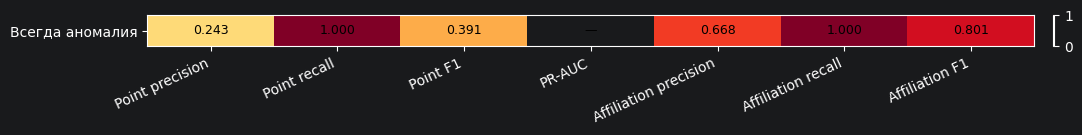

  Карта классификации: последние 50 000 точек теста


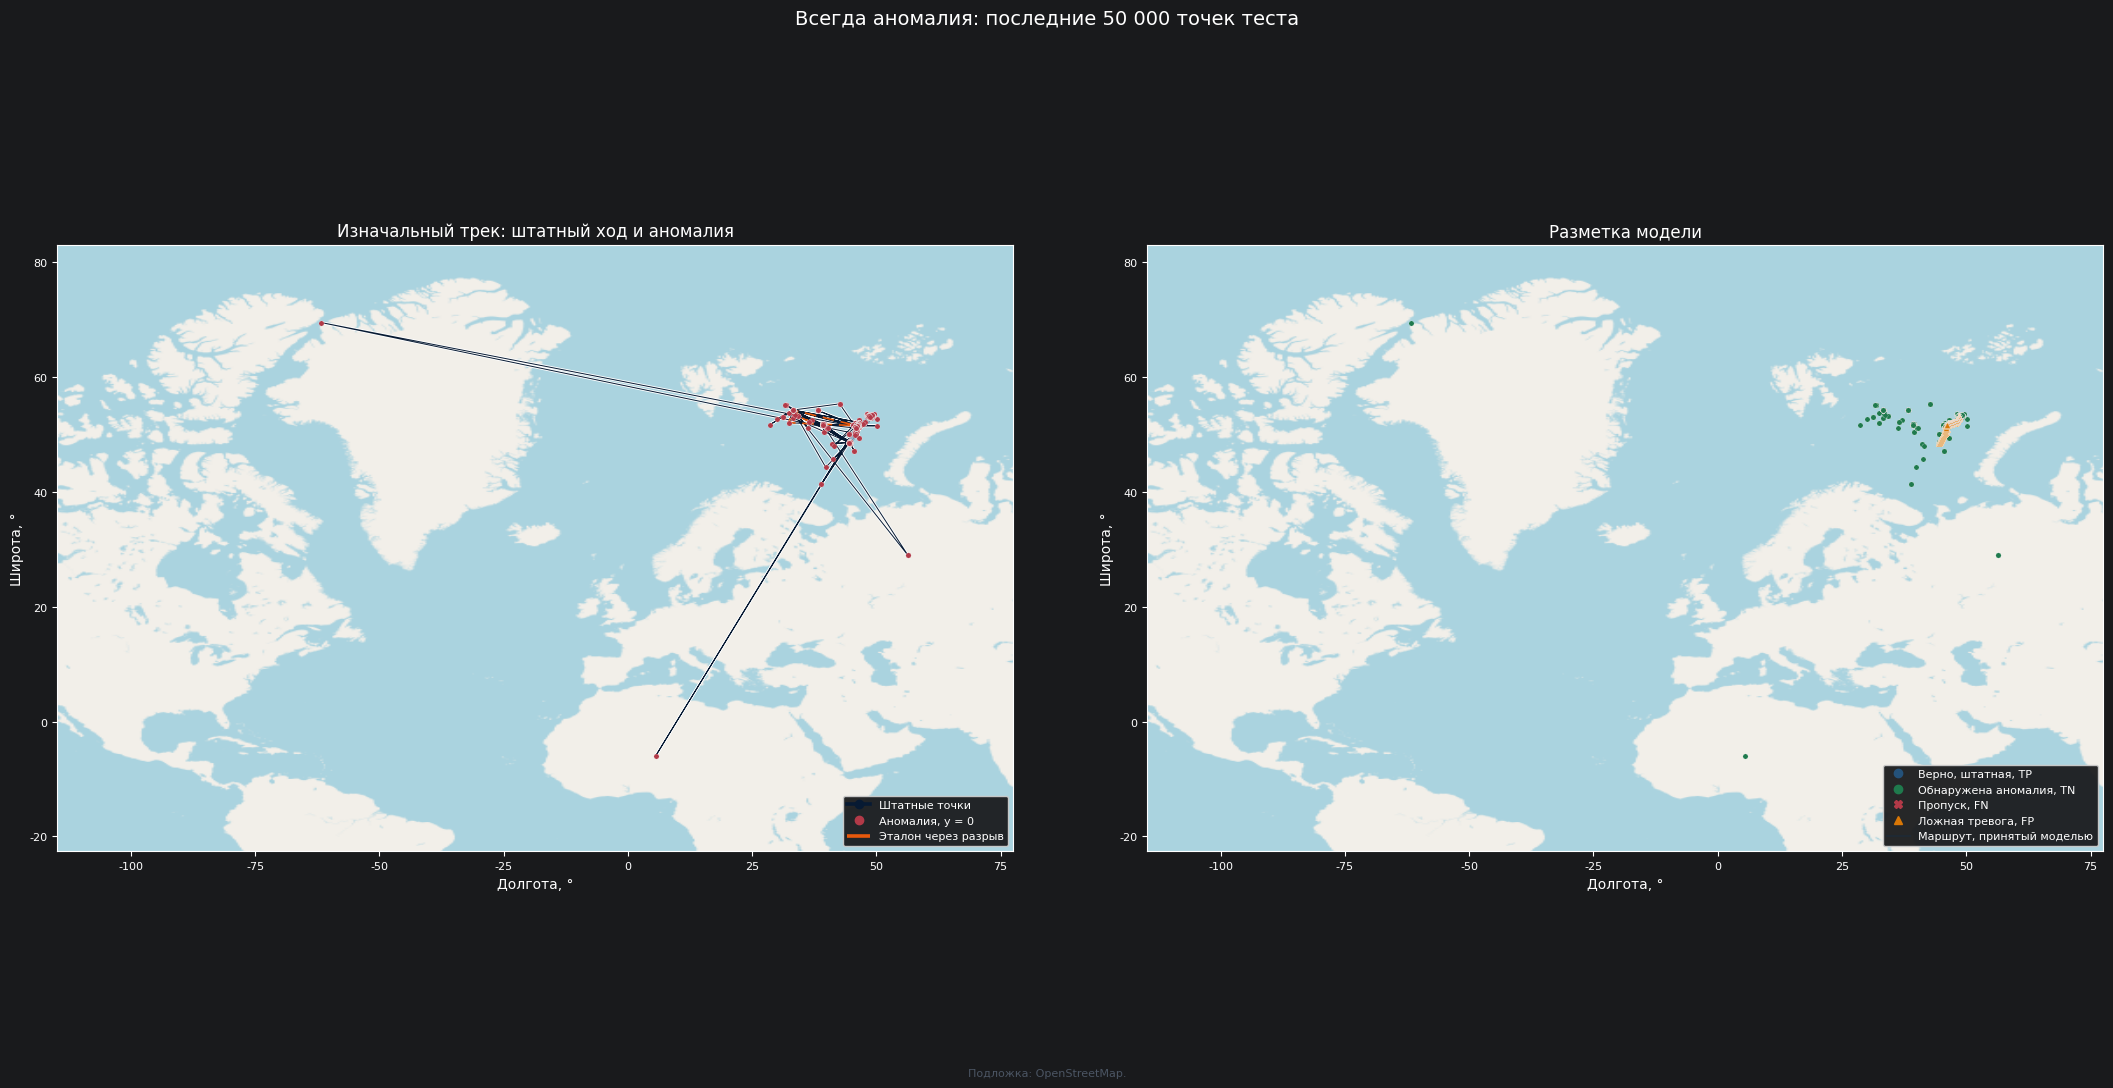

{'point_precision': 0.24293,
 'point_recall': 1.0,
 'point_f1': 0.39089892431593093,
 'pr_auc': nan,
 'affiliation_precision': 0.6681793645910251,
 'affiliation_recall': 1.0,
 'affiliation_f1': 0.8010881548757649,
 'geodesic_rmse': 0.0,
 'hausdorff_distance': 0.0,
 'distance_loss': 18749205.82274192,
 'distance_loss_ratio': 1.0,
 'detection_delay_mean': 0.0,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 0.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 51.0,
 'detection_delay_n_undetected': 0.0}

In [4]:
started = time.perf_counter()
show_result(
    "Всегда штатная",
    np.zeros(len(test["anom"]), dtype=bool),
    time.perf_counter() - started,
    "Каждая тестовая точка помечена штатной.",
)
started = time.perf_counter()
show_result(
    "Всегда аномалия",
    np.ones(len(test["anom"]), dtype=bool),
    time.perf_counter() - started,
    "Каждая тестовая точка помечена аномальной.",
)


# ARIMA(2, 1, 1)

Две независимые модели, по широте и по долготе. Коэффициенты оцениваются методом Хеннана–Риссанена на самом длинном гладком штатном участке обучения. На тесте — одношаговый прогноз; score — геодезическая ошибка, в метрах.


ARIMA(2, 1, 1)
  участок обучения: точки 77883–83994, длина 6111
  широта  c=-9.77e-06 φ1=1.508 φ2=-0.509 θ=-0.747
  долгота c=-0.000231 φ1=1.053 φ2=-0.055 θ=-0.516
  порог 13.45 м, F1 аномалий на хвосте обучения 0.995
ARIMA(2, 1, 1)
Порог геодезической ошибки 13.5 м. F1 аномалий на хвосте обучения 0.995.
  Помечено аномалиями на тесте: 99.8%   время 0.2 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2422
    Point recall                         0.9952
    Point F1                             0.3896
    PR-AUC                               0.8557
    Affiliation precision                0.6686
    Affiliation recall                   1.0000
    Affiliation F1                       0.8014
    Delay median, с                        0.00
    Delay mean, с                          0.20
    Delay p95, с                           0.00
    Events                                   51
    Detected                                 51
    

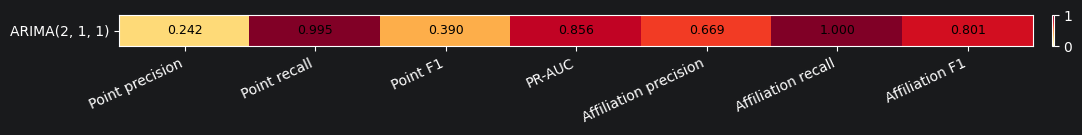

  Карта классификации: последние 50 000 точек теста


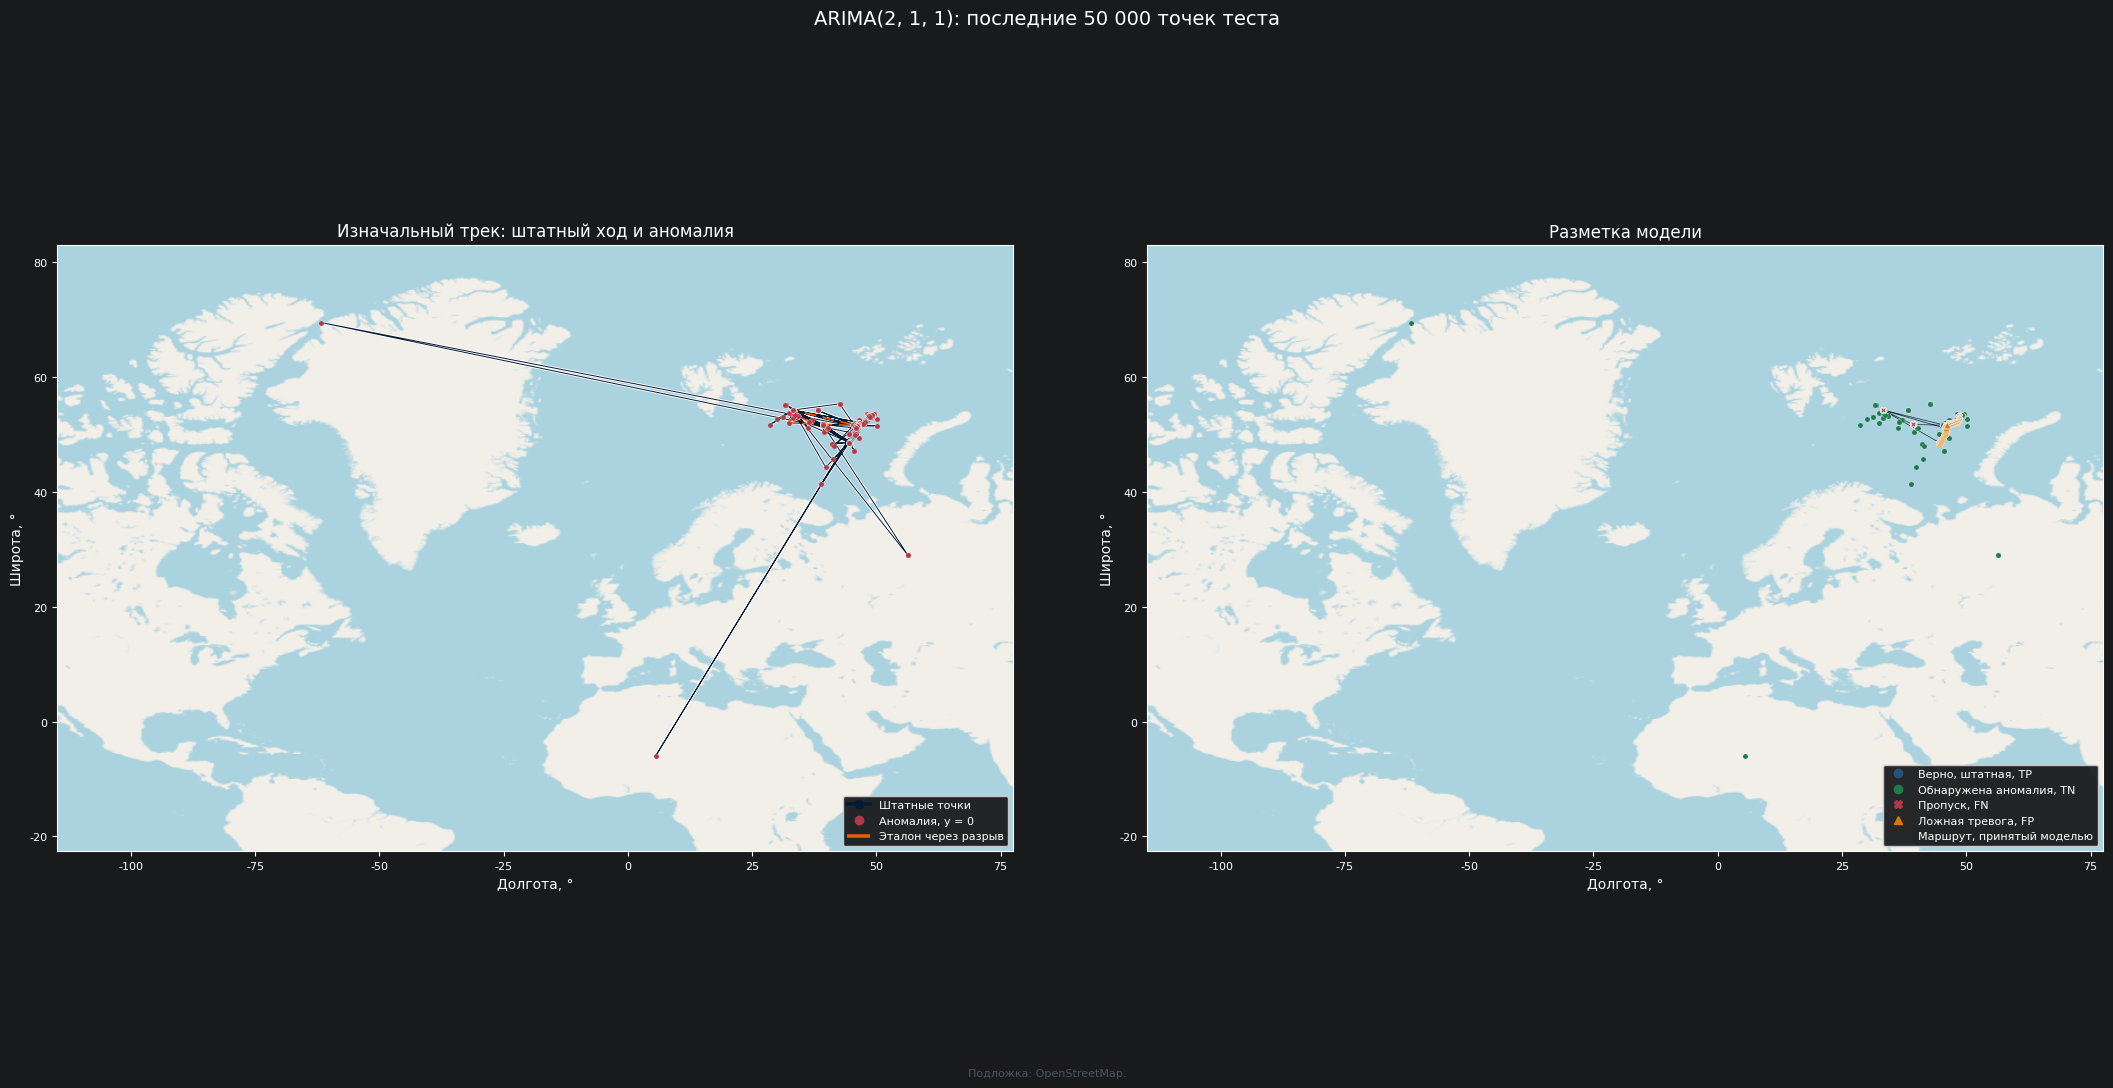

{'point_precision': 0.2422299260565497,
 'point_recall': 0.995183797801836,
 'point_f1': 0.38962441276722615,
 'pr_auc': 0.8557266952057843,
 'affiliation_precision': 0.668561467558723,
 'affiliation_recall': 0.9999839070011798,
 'affiliation_f1': 0.8013575400383126,
 'geodesic_rmse': 198665.66473258135,
 'hausdorff_distance': 925500.4655244661,
 'distance_loss': 9216393.525088672,
 'distance_loss_ratio': 0.4915618086558959,
 'detection_delay_mean': 0.19607843137254902,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 0.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 51.0,
 'detection_delay_n_undetected': 0.0}

In [5]:
def longest_smooth_slice(pack, max_dt=40.0, max_dist=2_000.0, min_len=80):
    good = pack["valid"].copy()
    good[1:] &= (pack["dt"][1:] <= max_dt) & (pack["dist"][1:] <= max_dist)
    padded = np.r_[False, good, False]
    change = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(change == 1)
    ends = np.flatnonzero(change == -1)
    if len(starts) == 0:
        raise RuntimeError("Нет гладкого штатного участка для ARIMA.")
    lengths = ends - starts
    best = int(np.argmax(lengths))
    if lengths[best] < min_len:
        raise RuntimeError("Самый длинный штатный участок короче 80 точек.")
    return int(starts[best]), int(ends[best])


def fit_arima_211(series):
    """Оценивает ARIMA(2, 1, 1): константу, два AR-коэффициента разностей и один MA."""
    series = np.asarray(series, dtype=float)
    delta = np.diff(series)
    constant = float(np.mean(delta))
    centered = delta - constant
    long_order = 12
    rows = len(centered) - long_order
    design = np.column_stack([centered[long_order - lag : len(centered) - lag] for lag in range(1, long_order + 1)])
    target = centered[long_order:]
    coef, *_ = np.linalg.lstsq(design, target, rcond=None)
    residual = np.zeros(len(centered))
    residual[long_order:] = target - design @ coef
    start = long_order + 1
    target2 = centered[start:]
    design2 = np.column_stack(
        [
            centered[start - 1 : len(centered) - 1],
            centered[start - 2 : len(centered) - 2],
            residual[start - 1 : len(centered) - 1],
        ]
    )
    beta, *_ = np.linalg.lstsq(design2, target2, rcond=None)
    phi1, phi2, theta = (float(item) for item in beta)
    while abs(phi1) > 1.8 or abs(phi2) > 0.95:
        phi1 *= 0.8
        phi2 *= 0.8
    return {"c": constant, "phi1": phi1, "phi2": phi2, "theta": theta}


def arima_forecast(series, params):
    """Одношаговый прогноз ARIMA(2, 1, 1) с обновлением по фактическому приращению."""
    predicted = np.empty(len(series))
    predicted[0] = series[0]
    prev_delta_1 = 0.0
    prev_delta_2 = 0.0
    prev_eps = 0.0
    for index in range(1, len(series)):
        delta_hat = (
            params["c"] + params["phi1"] * prev_delta_1 + params["phi2"] * prev_delta_2 + params["theta"] * prev_eps
        )
        predicted[index] = series[index - 1] + delta_hat
        delta = series[index] - series[index - 1]
        prev_eps = delta - delta_hat
        prev_delta_2 = prev_delta_1
        prev_delta_1 = delta
    return predicted


def arima_scores(pack, lat_params, lon_params):
    lat_hat = arima_forecast(pack["lat"], lat_params)
    lon_hat = arima_forecast(pack["lon"], lon_params)
    return haversine_m(pack["lat"], pack["lon"], lat_hat, lon_hat)


print("ARIMA(2, 1, 1)")
started = time.perf_counter()
span_start, span_end = longest_smooth_slice(fit)
print(f"  участок обучения: точки {span_start}–{span_end}, длина {span_end - span_start}")
lat_params = fit_arima_211(fit["lat"][span_start:span_end])
lon_params = fit_arima_211(fit["lon"][span_start:span_end])
print(
    f"  широта  c={lat_params['c']:.3g} φ1={lat_params['phi1']:.3f} φ2={lat_params['phi2']:.3f} θ={lat_params['theta']:.3f}"
)
print(
    f"  долгота c={lon_params['c']:.3g} φ1={lon_params['phi1']:.3f} φ2={lon_params['phi2']:.3f} θ={lon_params['theta']:.3f}"
)
val_scores = arima_scores(val, lat_params, lon_params)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = arima_scores(test, lat_params, lon_params)
print(f"  порог {tau:.4g} м, F1 аномалий на хвосте обучения {val_f1:.3f}")
show_result(
    "ARIMA(2, 1, 1)",
    test_scores > tau,
    time.perf_counter() - started,
    f"Порог геодезической ошибки {tau:.1f} м. F1 аномалий на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Фильтр Калмана, постоянная скорость

Состояние — положение и скорость в локальной проекции. Score — нормированный квадрат инновации, при согласованной модели он имеет распределение хи-квадрат с двумя степенями свободы. После разрыва дольше 180 секунд фильтр инициализируется заново, но сама инновация этого шага сохраняется.


Фильтр Калмана
  χ² 0.999 (df=2) = 13.82; выбранный порог 1.06e-05, F1 на хвосте обучения 0.995
Фильтр Калмана
Порог NIS 0.00. Теоретический χ²₀.₉₉₉ = 13.82. F1 на хвосте обучения 0.995.
  Помечено аномалиями на тесте: 95.1%   время 4.9 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2534
    Point recall                         0.9923
    Point F1                             0.4038
    PR-AUC                               0.8984
    Affiliation precision                0.6765
    Affiliation recall                   1.0000
    Affiliation F1                       0.8070
    Delay median, с                        0.00
    Delay mean, с                          0.20
    Delay p95, с                           0.00
    Events                                   51
    Detected                                 51
    Undetected                                0
    Geodesic RMSE, м                    4218.18
    Hausdorff, м            

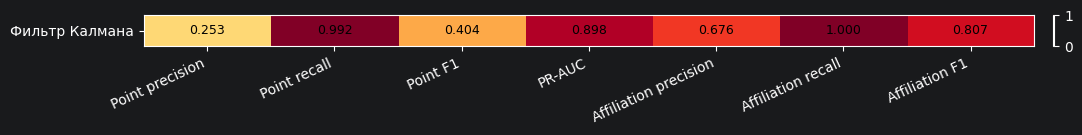

  Карта классификации: последние 50 000 точек теста


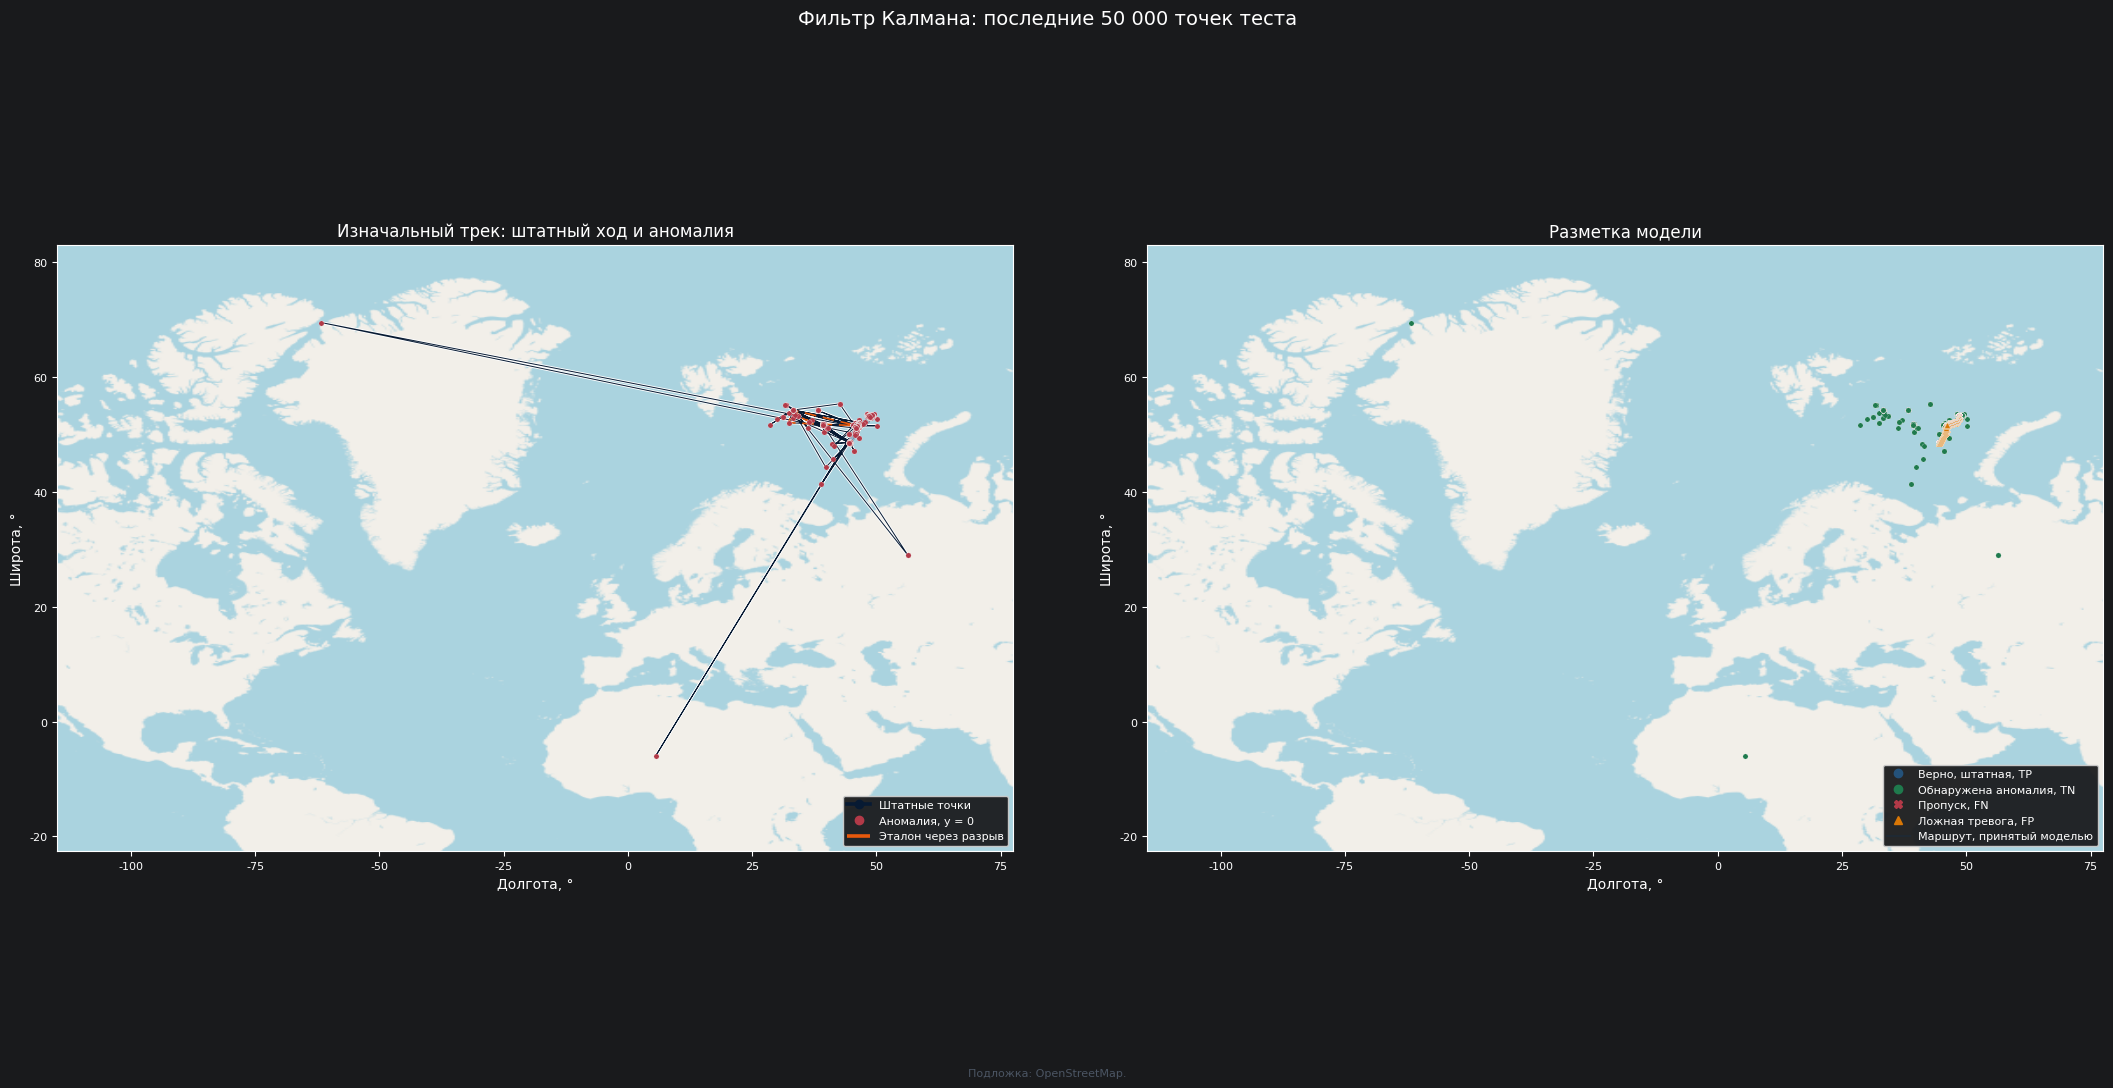

{'point_precision': 0.25344856590125325,
 'point_recall': 0.9923023093072079,
 'point_f1': 0.40376868640341695,
 'pr_auc': 0.8983828662878028,
 'affiliation_precision': 0.6764559613342532,
 'affiliation_recall': 0.999999823520381,
 'affiliation_f1': 0.8070070777467221,
 'geodesic_rmse': 4218.175396280286,
 'hausdorff_distance': 41669.11110550088,
 'distance_loss': 15374398.877721518,
 'distance_loss_ratio': 0.8200026722770883,
 'detection_delay_mean': 0.19607843137254902,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 0.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 51.0,
 'detection_delay_n_undetected': 0.0}

In [6]:
def process_noise(dt, sigma_acc):
    dt2 = dt * dt
    dt3 = dt2 * dt
    dt4 = dt2 * dt2
    noise = np.zeros((4, 4))
    noise[0, 0] = noise[1, 1] = dt4 / 4.0
    noise[2, 2] = noise[3, 3] = dt2
    noise[0, 2] = noise[2, 0] = noise[1, 3] = noise[3, 1] = dt3 / 2.0
    return noise * (sigma_acc**2)


def kalman_scores(pack, sigma_acc=0.35, sigma_meas=40.0):
    xy = pack["xy"]
    t_sec = pack["t"]
    count = len(xy)
    state = np.zeros(4)
    state[:2] = xy[0]
    cov = np.diag([80.0**2, 80.0**2, 5.0**2, 5.0**2])
    observation = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
    meas_cov = np.eye(2) * (sigma_meas**2)
    eye = np.eye(4)
    scores = np.zeros(count)
    for index in range(1, count):
        dt = float(t_sec[index] - t_sec[index - 1])
        dt = 1.0 if dt <= 0.0 else dt
        gap = dt > 180.0
        dt_model = min(dt, 45.0)
        transition = np.eye(4)
        transition[0, 2] = dt_model
        transition[1, 3] = dt_model
        pred = transition @ state
        pred_cov = transition @ cov @ transition.T + process_noise(dt_model, sigma_acc)
        innov = xy[index] - observation @ pred
        innov_cov = observation @ pred_cov @ observation.T + meas_cov
        solved = np.linalg.solve(innov_cov, innov)
        scores[index] = float(innov @ solved)
        gain = pred_cov @ observation.T @ np.linalg.inv(innov_cov)
        state = pred + gain @ innov
        cov = (eye - gain @ observation) @ pred_cov
        cov = 0.5 * (cov + cov.T)
        if gap:
            state = np.array([xy[index, 0], xy[index, 1], 0.0, 0.0])
            cov = np.diag([80.0**2, 80.0**2, 5.0**2, 5.0**2])
    return scores


print("Фильтр Калмана")
started = time.perf_counter()
chi_critical = float(chi2.ppf(0.999, 2))
val_scores = kalman_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"], extra=(chi_critical,))
test_scores = kalman_scores(test)
print(f"  χ² 0.999 (df=2) = {chi_critical:.2f}; выбранный порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Фильтр Калмана",
    test_scores > tau,
    time.perf_counter() - started,
    f"Порог NIS {tau:.2f}. Теоретический χ²₀.₉₉₉ = {chi_critical:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Bootstrap particle filter (SIR)

Те же положение и скорость, но вместо одного гауссовского состояния держится набор гипотез. После ресэмплинга веса равны, и score — минус логарифм средней правдоподобности измерения.


Particle filter
  частиц 32, порог 10.2, F1 на хвосте обучения 0.995
Particle filter
SIR, частиц 32. Порог 10.25. F1 на хвосте обучения 0.995.
  Помечено аномалиями на тесте: 97.0%   время 18.3 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2433
    Point recall                         0.9719
    Point F1                             0.3892
    PR-AUC                               0.7497
    Affiliation precision                0.6611
    Affiliation recall                   0.9945
    Affiliation F1                       0.7942
    Delay median, с                        0.00
    Delay mean, с                          0.20
    Delay p95, с                           0.00
    Events                                   51
    Detected                                 51
    Undetected                                0
    Geodesic RMSE, м                  200133.45
    Hausdorff, м                      925753.30
    Distance loss, м   

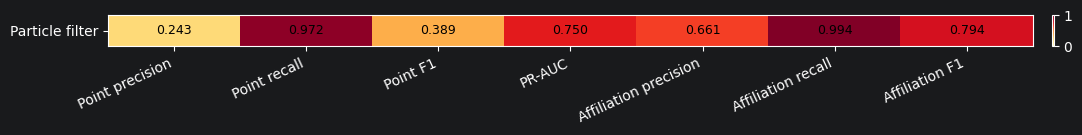

  Карта классификации: последние 50 000 точек теста


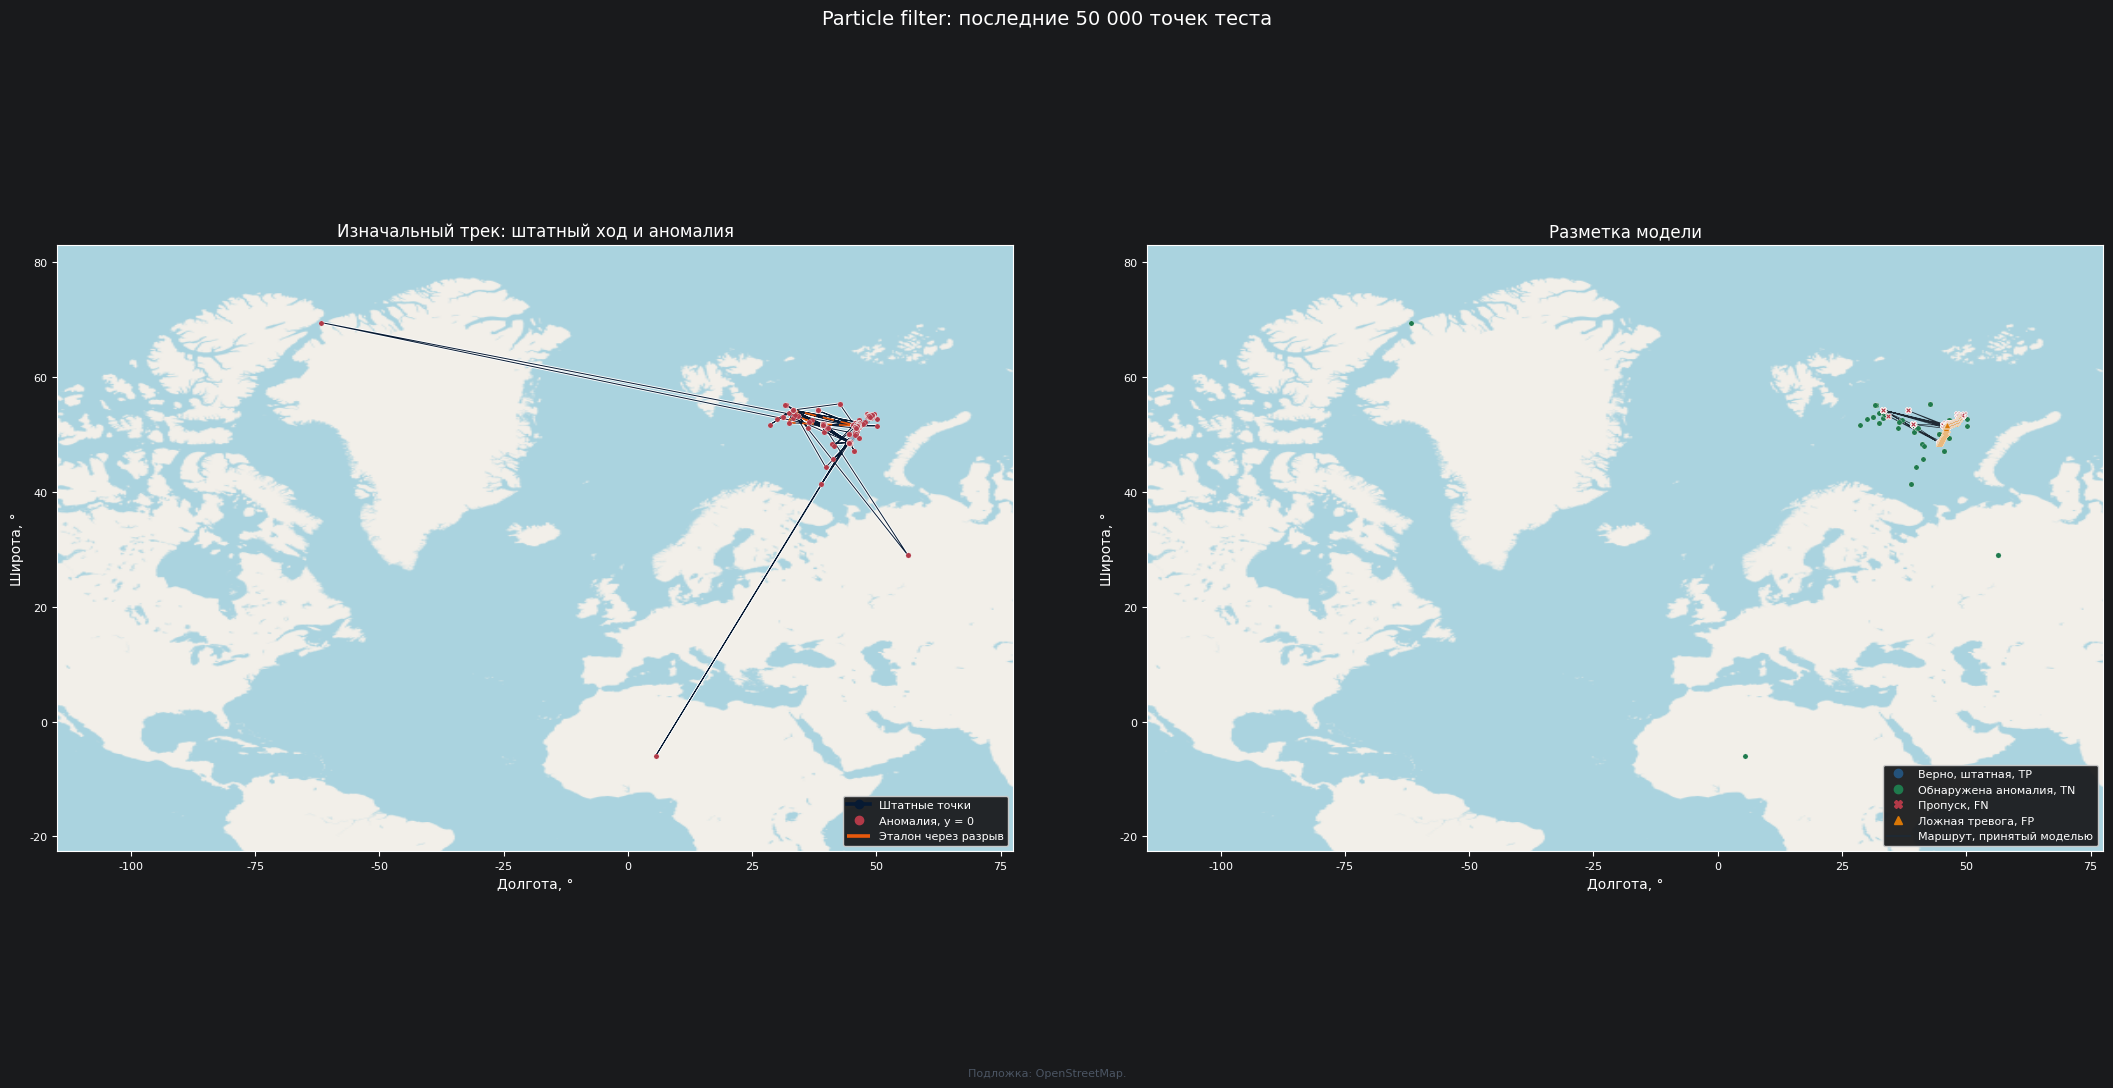

{'point_precision': 0.2433443616462076,
 'point_recall': 0.9718849051167003,
 'point_f1': 0.38923142866563354,
 'pr_auc': 0.749733693340578,
 'affiliation_precision': 0.6610850633869524,
 'affiliation_recall': 0.99447319530279,
 'affiliation_f1': 0.7942111029951681,
 'geodesic_rmse': 200133.44920846395,
 'hausdorff_distance': 925753.2958479904,
 'distance_loss': 17215191.132850878,
 'distance_loss_ratio': 0.9181824177304432,
 'detection_delay_mean': 0.19607843137254902,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 0.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 51.0,
 'detection_delay_n_undetected': 0.0}

In [7]:
def systematic_resample(log_weights, generator):
    shifted = np.exp(log_weights - np.max(log_weights))
    weights = shifted / shifted.sum()
    positions = (np.arange(len(weights)) + generator.random()) / len(weights)
    cumulative = np.cumsum(weights)
    cumulative[-1] = 1.0
    return np.searchsorted(cumulative, positions, side="left").clip(0, len(weights) - 1)


def particle_scores(pack, n_particles=N_PARTICLES, sigma_acc=0.45, sigma_meas=40.0, seed=SEED):
    generator = np.random.default_rng(seed)
    xy = pack["xy"]
    t_sec = pack["t"]
    count = len(xy)
    particles = np.zeros((n_particles, 4))
    particles[:, :2] = xy[0]
    particles[:, 2:] = generator.normal(0.0, 1.0, size=(n_particles, 2))
    scores = np.zeros(count)
    r_var = sigma_meas**2
    log_const = np.log(2.0 * np.pi * r_var)
    for index in range(1, count):
        dt = float(t_sec[index] - t_sec[index - 1])
        dt = 1.0 if dt <= 0.0 else dt
        gap = dt > 180.0
        dt_model = min(dt, 45.0)
        particles[:, 0] += particles[:, 2] * dt_model
        particles[:, 1] += particles[:, 3] * dt_model
        particles[:, 0] += generator.normal(0.0, sigma_acc * dt_model**2 / 2.0, n_particles)
        particles[:, 1] += generator.normal(0.0, sigma_acc * dt_model**2 / 2.0, n_particles)
        particles[:, 2] += generator.normal(0.0, sigma_acc * dt_model, n_particles)
        particles[:, 3] += generator.normal(0.0, sigma_acc * dt_model, n_particles)
        diff = xy[index] - particles[:, :2]
        loglik = -0.5 * (np.sum(diff * diff, axis=1) / r_var + 2.0 * log_const)
        scores[index] = float(-logsumexp(loglik) + np.log(n_particles))
        draw = systematic_resample(loglik, generator)
        particles = particles[draw]
        if gap or scores[index] > 40.0:
            particles[:, :2] = xy[index]
            particles[:, 2:] = generator.normal(0.0, 1.0, size=(n_particles, 2))
    return scores


print("Particle filter")
started = time.perf_counter()
val_scores = particle_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = particle_scores(test)
print(f"  частиц {N_PARTICLES}, порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Particle filter",
    test_scores > tau,
    time.perf_counter() - started,
    f"SIR, частиц {N_PARTICLES}. Порог {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Gaussian process

Два независимых GP с RBF-ядром описывают восточную и северную координату как функции времени. Точная ковариация строится по 250 штатным точкам обучения, равномерно разложенным по времени. Score — сумма квадратов нормированных остатков по двум координатам.


Gaussian process
  опорных точек 250, длина корреляции 48 ч, порог 5.53, F1 0.995
Gaussian process
RBF, опорных штатных точек 250, ℓ = 2 суток. Порог 5.53. F1 на хвосте обучения 0.995.
  Помечено аномалиями на тесте: 33.9%   время 2.7 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2362
    Point recall                         0.3298
    Point F1                             0.2752
    PR-AUC                               0.3388
    Affiliation precision                0.7994
    Affiliation recall                   0.5398
    Affiliation F1                       0.6444
    Delay median, с                        0.00
    Delay mean, с                       3287.52
    Delay p95, с                       19888.00
    Events                                   51
    Detected                                 29
    Undetected                               22
    Geodesic RMSE, м                  156795.04
    Hausdorff, м              

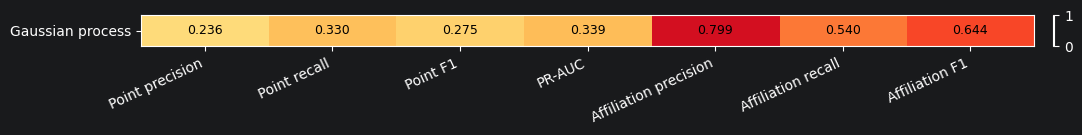

  Карта классификации: последние 50 000 точек теста


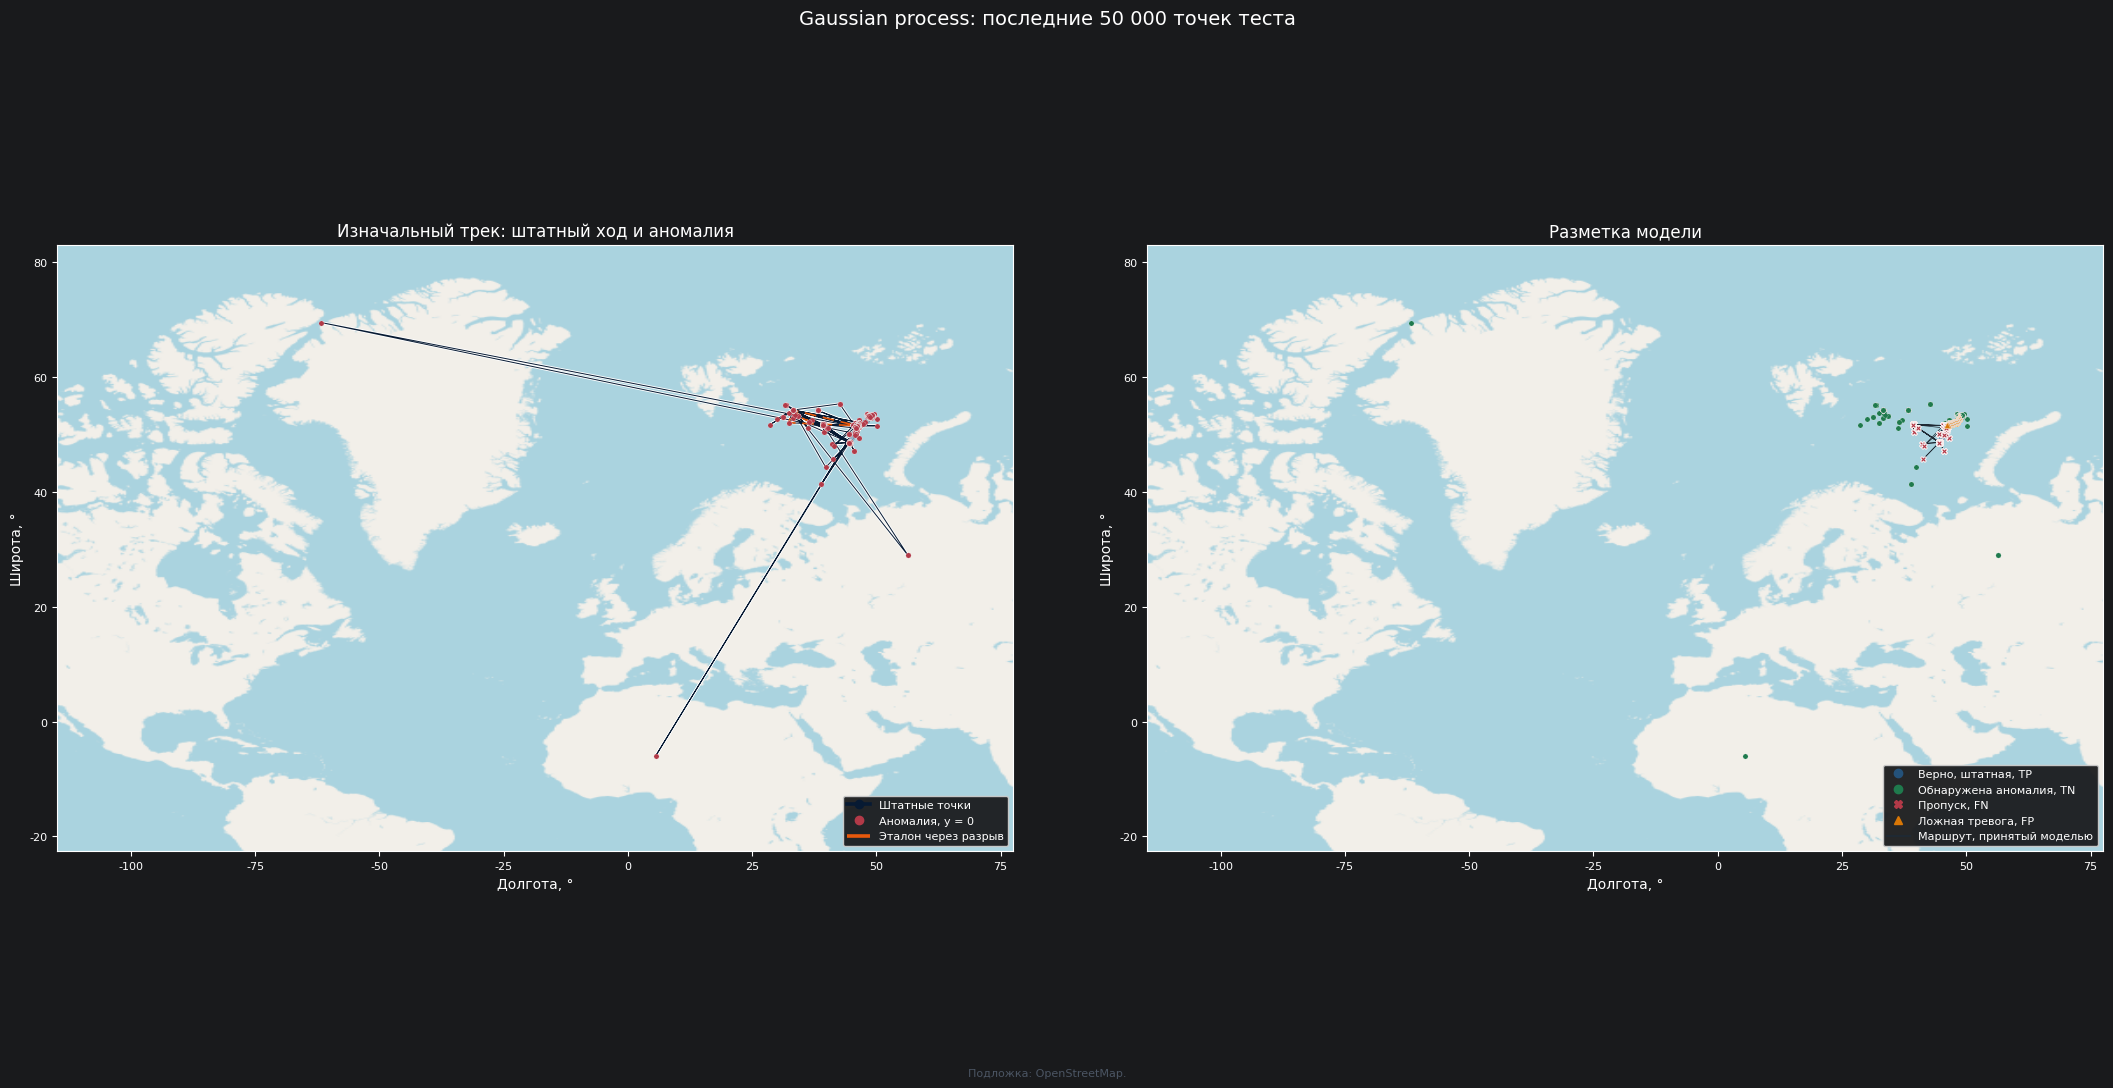

{'point_precision': 0.23619423887725918,
 'point_recall': 0.3297657761495081,
 'point_f1': 0.27524480329840234,
 'pr_auc': 0.3387851867895077,
 'affiliation_precision': 0.7993542599470997,
 'affiliation_recall': 0.5398180690433932,
 'affiliation_f1': 0.6444366624742547,
 'geodesic_rmse': 156795.04461970887,
 'hausdorff_distance': 572692.634610255,
 'distance_loss': 25151034.45035761,
 'distance_loss_ratio': 1.3414453224387013,
 'detection_delay_mean': 3287.5172413793102,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 19887.99999999998,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 29.0,
 'detection_delay_n_undetected': 22.0}

In [8]:
def rbf(left, right, lengthscale, signal):
    gap = left.reshape(-1, 1) - right.reshape(1, -1)
    return (signal**2) * np.exp(-0.5 * gap * gap / lengthscale**2)


def gp_predict(t_train, y_train, t_test, lengthscale, noise, signal):
    center = float(np.mean(y_train))
    target = y_train - center
    chol = None
    jitter = 1e-4 * signal**2
    for _ in range(6):
        gram = rbf(t_train, t_train, lengthscale, signal)
        gram.flat[:: len(t_train) + 1] += noise**2 + jitter
        try:
            chol = np.linalg.cholesky(gram)
            break
        except np.linalg.LinAlgError:
            jitter *= 10.0
    if chol is None:
        raise np.linalg.LinAlgError("Ковариация GP не разложилась.")
    alpha = np.linalg.solve(chol.T, np.linalg.solve(chol, target))
    mean = np.empty(len(t_test))
    variance = np.empty(len(t_test))
    batch = 2_500
    for start in range(0, len(t_test), batch):
        chunk = t_test[start : start + batch]
        cross = rbf(t_train, chunk, lengthscale, signal)
        mean[start : start + len(chunk)] = cross.T @ alpha + center
        solved = np.linalg.solve(chol, cross)
        variance[start : start + len(chunk)] = signal**2 + noise**2 - np.sum(solved * solved, axis=0)
    return mean, np.clip(variance, 1e-6, None)


def gp_scores(pack, t_train, x_train, y_train, lengthscale, noise):
    signal_x = float(np.std(x_train) + 1.0)
    signal_y = float(np.std(y_train) + 1.0)
    mean_x, var_x = gp_predict(t_train, x_train, pack["t"], lengthscale, noise, signal_x)
    mean_y, var_y = gp_predict(t_train, y_train, pack["t"], lengthscale, noise, signal_y)
    return (pack["xy"][:, 0] - mean_x) ** 2 / var_x + (pack["xy"][:, 1] - mean_y) ** 2 / var_y


print("Gaussian process")
started = time.perf_counter()
normal_index = np.flatnonzero(fit["valid"])
gp_count = 250
grid = np.linspace(0, len(normal_index) - 1, gp_count).astype(int)
chosen = normal_index[grid]
t_gp = fit["t"][chosen]
x_gp = fit["xy"][chosen, 0]
y_gp = fit["xy"][chosen, 1]
lengthscale = 2.0 * 24.0 * 3600.0
noise = 150.0
val_scores = gp_scores(val, t_gp, x_gp, y_gp, lengthscale, noise)
tau, val_f1 = select_threshold(val_scores, val["anom"], extra=(chi2.ppf(0.999, 2),))
test_scores = gp_scores(test, t_gp, x_gp, y_gp, lengthscale, noise)
print(f"  опорных точек {gp_count}, длина корреляции {lengthscale / 3600:.0f} ч, порог {tau:.3g}, F1 {val_f1:.3f}")
show_result(
    "Gaussian process",
    test_scores > tau,
    time.perf_counter() - started,
    f"RBF, опорных штатных точек {gp_count}, ℓ = 2 суток. Порог {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Скрытая марковская модель

Наблюдение точки — скорость, ускорение и поворот курса. Одна гауссовская HMM учится на штатных отрезках, две — на аномальных: общий режим и быстрые участки. Point-wise score — максимум разности предсказательных логарифмов правдоподобия аномальной и штатной модели.


HMM
  штатных отрезков 6, аномальных 6, быстрых 6
  порог -2.36, F1 на хвосте обучения 0.995
HMM
Гауссовские HMM, аномальных моделей 2. Порог -2.36. F1 на хвосте обучения 0.995.
  Помечено аномалиями на тесте: 57.7%   время 87.4 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.3962
    Point recall                         0.9408
    Point F1                             0.5575
    PR-AUC                               0.7159
    Affiliation precision                0.7178
    Affiliation recall                   0.9998
    Affiliation F1                       0.8357
    Delay median, с                        0.00
    Delay mean, с                          0.40
    Delay p95, с                           0.00
    Events                                   51
    Detected                                 50
    Undetected                                1
    Geodesic RMSE, м                   80445.15
    Hausdorff, м                    

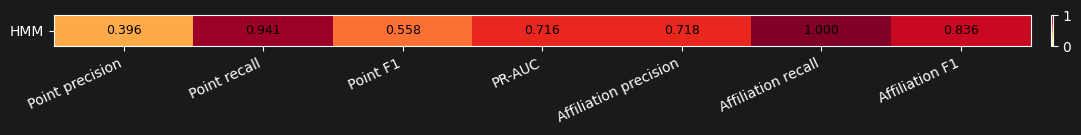

  Карта классификации: последние 50 000 точек теста


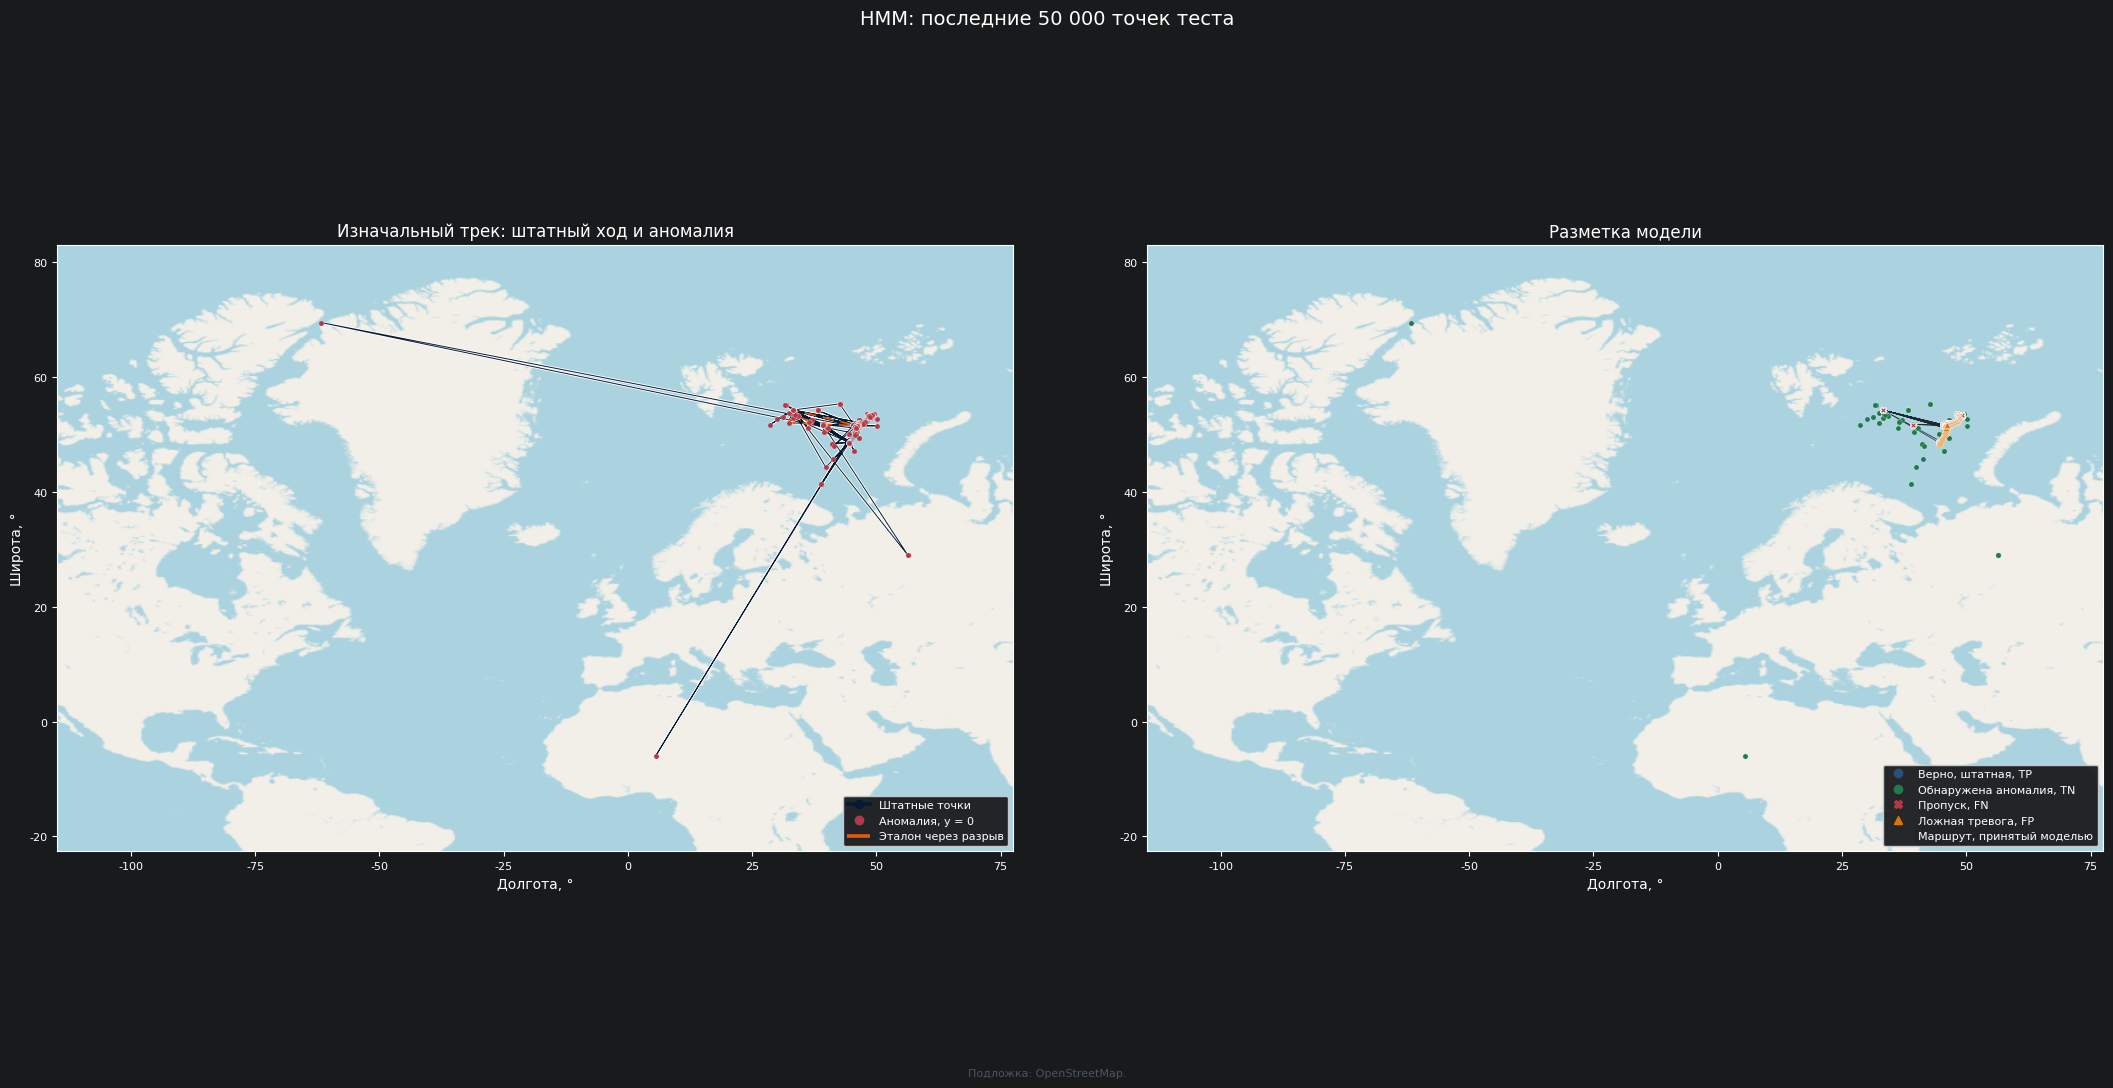

{'point_precision': 0.39616231301242827,
 'point_recall': 0.9408059934960689,
 'point_f1': 0.5575478142076503,
 'pr_auc': 0.7159499436457925,
 'affiliation_precision': 0.7177966201726698,
 'affiliation_recall': 0.9998060451364543,
 'affiliation_f1': 0.8356500773105063,
 'geodesic_rmse': 80445.15094590443,
 'hausdorff_distance': 999783.1049978196,
 'distance_loss': 11145627.258515231,
 'distance_loss_ratio': 0.594458632748919,
 'detection_delay_mean': 0.4,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 0.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 50.0,
 'detection_delay_n_undetected': 1.0}

In [9]:
class DiagHMM:
    """HMM с диагональными гауссовскими эмиссиями и несколькими последовательностями."""

    def __init__(self, n_states=3, n_iter=8, seed=SEED):
        self.n_states = n_states
        self.n_iter = n_iter
        self.rng = np.random.default_rng(seed)

    def _log_emit(self, values):
        diff = values[:, None, :] - self.mean[None, :, :]
        quad = np.sum(diff * diff / self.var[None, :, :], axis=-1)
        logdet = np.sum(np.log(2.0 * np.pi * self.var), axis=-1)
        return -0.5 * (quad + logdet)

    def _forward(self, log_emit):
        length, _ = log_emit.shape
        log_alpha = np.empty_like(log_emit)
        log_trans = np.log(self.trans + 1e-16)
        log_alpha[0] = np.log(self.start + 1e-16) + log_emit[0]
        for index in range(1, length):
            log_alpha[index] = log_emit[index] + logsumexp(log_alpha[index - 1][:, None] + log_trans, axis=0)
        return log_alpha

    def _backward(self, log_emit):
        length, _ = log_emit.shape
        log_beta = np.zeros_like(log_emit)
        log_trans = np.log(self.trans + 1e-16)
        for index in range(length - 2, -1, -1):
            log_beta[index] = logsumexp(
                log_trans + log_emit[index + 1][None, :] + log_beta[index + 1][None, :],
                axis=1,
            )
        return log_beta

    def fit(self, sequences):
        stacked = np.concatenate(sequences, axis=0)
        width = stacked.shape[1]
        levels = np.linspace(0.2, 0.8, self.n_states)
        self.mean = np.quantile(stacked, levels, axis=0)
        self.mean = self.mean + self.rng.normal(0.0, 0.01, size=self.mean.shape)
        base_var = np.var(stacked, axis=0) + 1e-2
        self.var = np.repeat(base_var[None, :], self.n_states, axis=0)
        self.trans = np.full((self.n_states, self.n_states), 1.0 / self.n_states)
        self.start = np.full(self.n_states, 1.0 / self.n_states)
        for _ in range(self.n_iter):
            start_acc = np.zeros(self.n_states)
            trans_acc = np.zeros_like(self.trans)
            mean_acc = np.zeros((self.n_states, width))
            var_acc = np.zeros((self.n_states, width))
            weight = np.zeros(self.n_states)
            for seq in sequences:
                log_emit = self._log_emit(seq)
                log_alpha = self._forward(log_emit)
                log_beta = self._backward(log_emit)
                log_gamma = log_alpha + log_beta
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)
                log_xi = (
                    log_alpha[:-1, :, None]
                    + np.log(self.trans + 1e-16)[None, :, :]
                    + log_emit[1:, None, :]
                    + log_beta[1:, None, :]
                )
                log_xi -= logsumexp(log_xi.reshape(len(seq) - 1, -1), axis=1)[:, None, None]
                start_acc += gamma[0]
                trans_acc += np.exp(log_xi).sum(axis=0)
                weight += gamma.sum(axis=0)
                mean_acc += gamma.T @ seq
                for state in range(self.n_states):
                    diff = seq - self.mean[state]
                    var_acc[state] += (gamma[:, state : state + 1] * (diff * diff)).sum(axis=0)
            self.start = start_acc / start_acc.sum()
            self.trans = trans_acc / np.maximum(trans_acc.sum(axis=1, keepdims=True), 1e-12)
            self.mean = mean_acc / np.maximum(weight[:, None], 1e-8)
            self.var = var_acc / np.maximum(weight[:, None], 1e-8) + 1e-2
        return self

    def predictive_loglik(self, values):
        log_emit = self._log_emit(values)
        log_trans = np.log(self.trans + 1e-16)
        log_filt = np.log(self.start + 1e-16)
        output = np.empty(len(values))
        for index in range(len(values)):
            log_pred = log_filt if index == 0 else logsumexp(log_filt[:, None] + log_trans, axis=0)
            joint = log_pred + log_emit[index]
            output[index] = logsumexp(joint)
            log_filt = joint - output[index]
        return output


def class_sequences(pack, mask, max_sequences=6, max_len=1_200, min_len=30, max_dt=90.0):
    flag = mask.copy()
    flag[1:] &= pack["dt"][1:] <= max_dt
    padded = np.r_[False, flag, False]
    change = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(change == 1)
    ends = np.flatnonzero(change == -1)
    order = np.argsort(-(ends - starts))
    sequences = []
    for index in order:
        if ends[index] - starts[index] < min_len:
            break
        stop = min(ends[index], starts[index] + max_len)
        sequences.append(kinematic_matrix(pack, slice(int(starts[index]), int(stop))))
        if len(sequences) >= max_sequences:
            break
    return sequences


def hmm_scores(pack, normal_model, anomaly_models):
    values = kinematic_matrix(pack)
    normal_log = normal_model.predictive_loglik(values)
    anomaly_log = np.vstack([model.predictive_loglik(values) for model in anomaly_models])
    return anomaly_log.max(axis=0) - normal_log


print("HMM")
started = time.perf_counter()
normal_seqs = class_sequences(fit, fit["valid"])
anomaly_seqs = class_sequences(fit, fit["anom"])
fast_seqs = class_sequences(fit, fit["anom"] & (fit["speed"] >= 8.0), min_len=20)
print(f"  штатных отрезков {len(normal_seqs)}, аномальных {len(anomaly_seqs)}, быстрых {len(fast_seqs)}")
if not normal_seqs or not anomaly_seqs:
    raise RuntimeError("Для HMM не нашлось отрезков обоих классов.")
iterations = 8
normal_model = DiagHMM(n_states=3, n_iter=iterations, seed=SEED).fit(normal_seqs)
anomaly_models = [DiagHMM(n_states=3, n_iter=iterations, seed=SEED + 1).fit(anomaly_seqs)]
if fast_seqs:
    anomaly_models.append(DiagHMM(n_states=2, n_iter=iterations, seed=SEED + 2).fit(fast_seqs))
val_scores = hmm_scores(val, normal_model, anomaly_models)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = hmm_scores(test, normal_model, anomaly_models)
print(f"  порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "HMM",
    test_scores > tau,
    time.perf_counter() - started,
    f"Гауссовские HMM, аномальных моделей {len(anomaly_models)}. Порог {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Фильтр Хэмпела

В центрированном окне скорость сравнивается с медианой соседей. Score — отклонение в единицах MAD. Окно видит будущие точки: это пакетный вариант фильтра, не онлайн-поток.


Hampel
  полуокно 10, порог 0, F1 на хвосте обучения 0.968
Hampel
Окно 21 точка по скорости. Порог 0.00. F1 на хвосте обучения 0.968.
  Помечено аномалиями на тесте: 92.8%   время 0.1 с
  CalculateMetrics, положительный класс — аномалия (метка 0)
    Point precision                      0.2470
    Point recall                         0.9433
    Point F1                             0.3915
    PR-AUC                               0.3515
    Affiliation precision                0.6696
    Affiliation recall                   0.9978
    Affiliation F1                       0.8014
    Delay median, с                        0.00
    Delay mean, с                          1.40
    Delay p95, с                          10.00
    Events                                   51
    Detected                                 50
    Undetected                                1
    Geodesic RMSE, м                  242459.92
    Hausdorff, м                     1000112.81
    Distance loss, м             

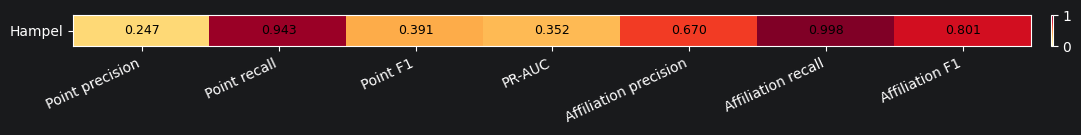

  Карта классификации: последние 50 000 точек теста


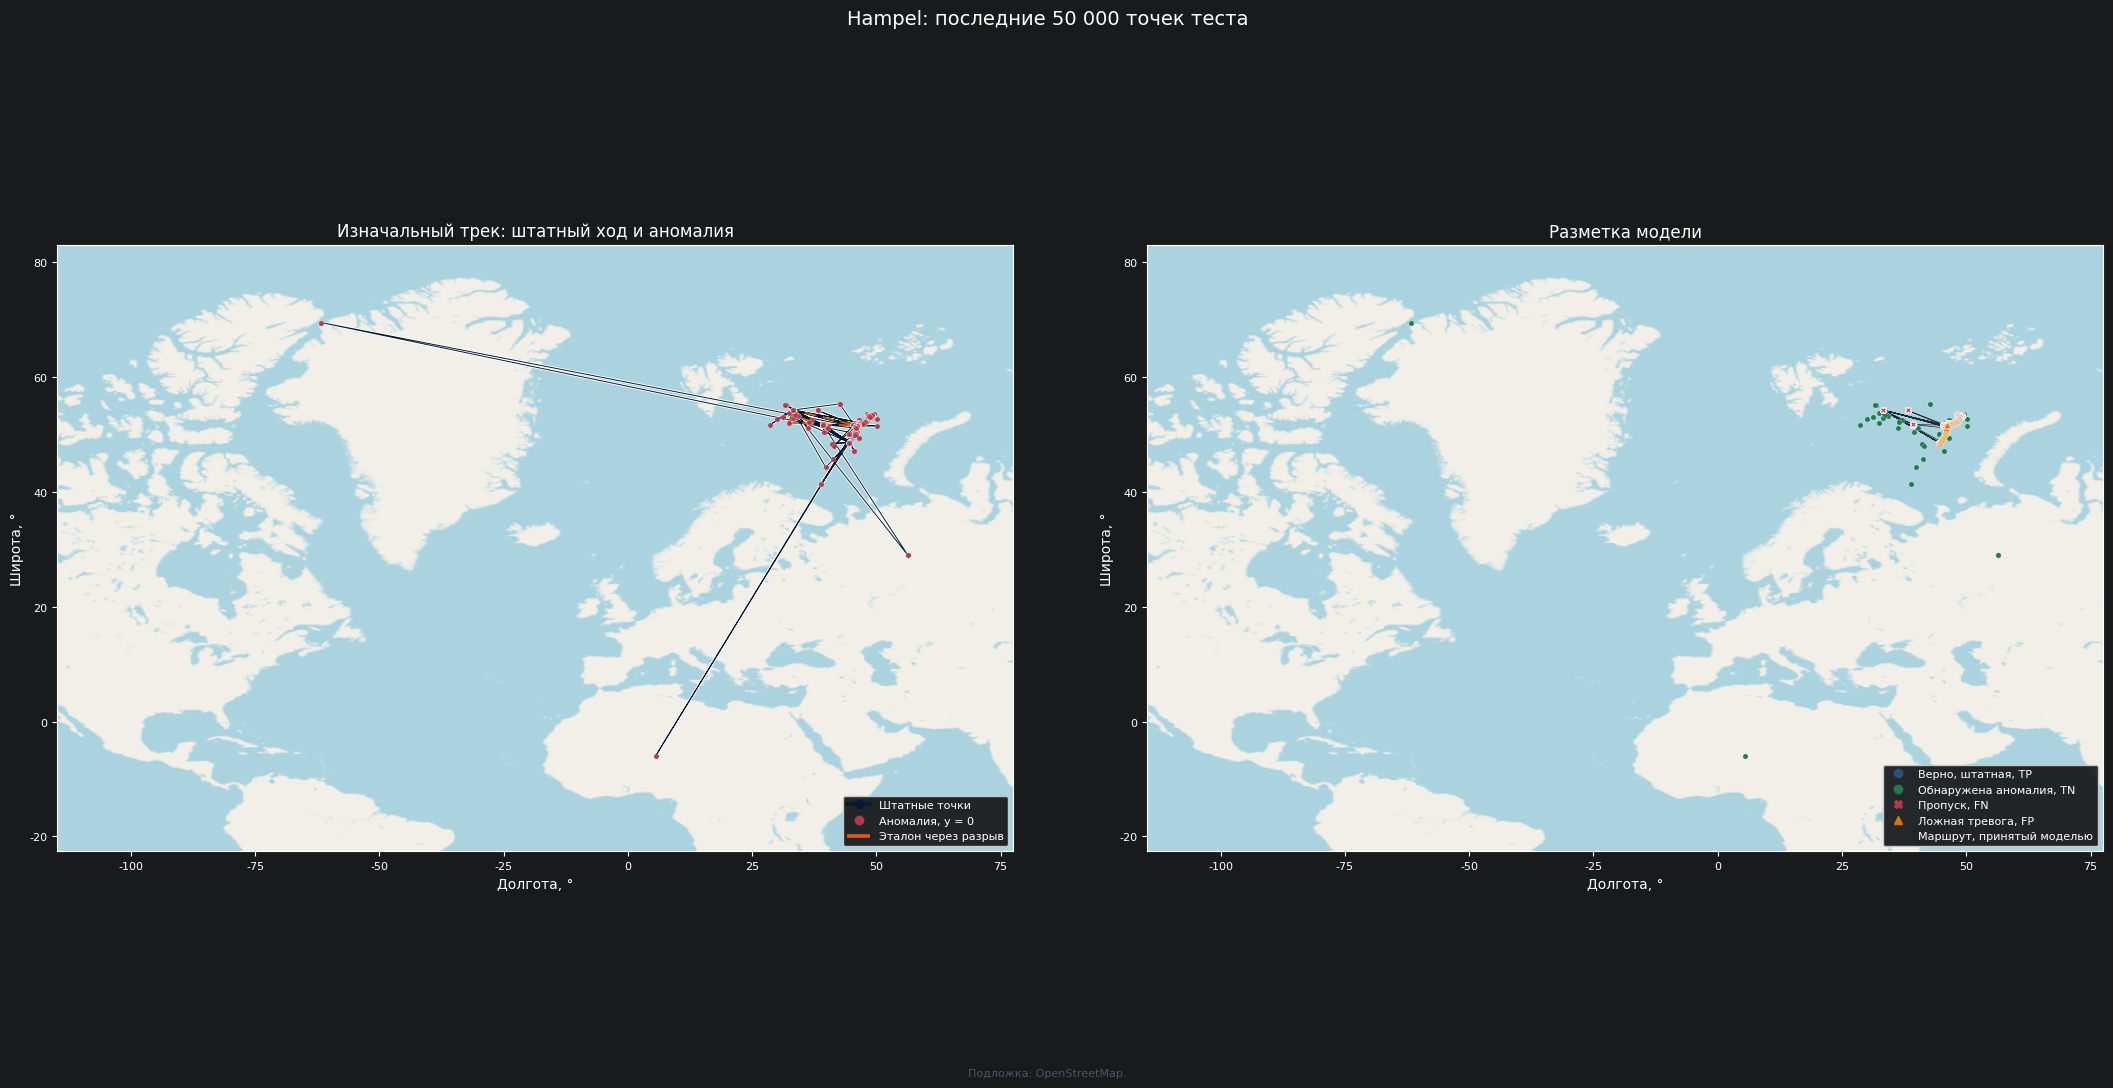

{'point_precision': 0.24698743236543147,
 'point_recall': 0.9432758407771786,
 'point_f1': 0.39147184187373474,
 'pr_auc': 0.3515448402127722,
 'affiliation_precision': 0.6696387748999431,
 'affiliation_recall': 0.997761498691323,
 'affiliation_f1': 0.8014149909990617,
 'geodesic_rmse': 242459.92293577513,
 'hausdorff_distance': 1000112.8112504066,
 'distance_loss': 26361991.202544063,
 'distance_loss_ratio': 1.4060324182141193,
 'detection_delay_mean': 1.4,
 'detection_delay_median': 0.0,
 'detection_delay_p95': 10.0,
 'detection_delay_n_events': 51.0,
 'detection_delay_n_detected': 50.0,
 'detection_delay_n_undetected': 1.0}

In [10]:
def hampel_scores(speed, half_window=10):
    padded = np.pad(speed, half_window, mode="edge")
    windows = np.lib.stride_tricks.sliding_window_view(padded, 2 * half_window + 1)
    center = np.median(windows, axis=1)
    mad = np.median(np.abs(windows - center[:, None]), axis=1)
    return np.abs(speed - center) / (1.4826 * mad + 1e-9)


print("Hampel")
started = time.perf_counter()
val_scores = hampel_scores(val["speed"])
tau, val_f1 = select_threshold(val_scores, val["anom"], extra=(3.0, 3.5, 5.0))
test_scores = hampel_scores(test["speed"])
print(f"  полуокно 10, порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Hampel",
    test_scores > tau,
    time.perf_counter() - started,
    f"Окно 21 точка по скорости. Порог {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# DBSCAN

Признаки точки — проекция, скорость и поворот курса. Кластеры строятся по всему тестовому набору: шумовая метка `-1` и есть аномалия. Радиус `eps` подбирается по хвосту обучения, шкала признаков — робастная, по штатным точкам обучения, чтобы `eps` на валидации и на тесте был в одних единицах.

Непрерывный score для PR-AUC — адаптация поверх меток DBSCAN: максимум из k-distance до `MinPts`-го соседа и расстояния до ближайшей core-точки. Большее значение — точка сильнее изолирована от плотного режима движения.


In [11]:
from sklearn.cluster import DBSCAN


def density_matrix(pack):
    return np.column_stack([pack["xy"], pack["speed"], pack["dpsi"]])


def dbscan_anomaly_scores(features, min_samples, labels=None, core_indices=None):
    """k-distance и расстояние до ближайшей core-точки. Больше — более аномально."""
    neighbors = NearestNeighbors(n_neighbors=min_samples, algorithm="kd_tree").fit(features)
    k_distance = neighbors.kneighbors(features)[0][:, -1]
    if core_indices is None or len(core_indices) == 0:
        return k_distance
    core_nn = NearestNeighbors(n_neighbors=1, algorithm="kd_tree").fit(features[core_indices])
    core_distance = core_nn.kneighbors(features)[0][:, 0]
    return np.maximum(k_distance, core_distance)


print("DBSCAN")
started = time.perf_counter()
center, scale = robust_params(density_matrix(fit)[fit["valid"]])
val_x = apply_robust(density_matrix(val), center, scale)
test_x = apply_robust(density_matrix(test), center, scale)
min_samples = 8
neighbors = NearestNeighbors(n_neighbors=min_samples, algorithm="kd_tree").fit(val_x)
distances, _ = neighbors.kneighbors(val_x)
k_distance = np.sort(distances[:, -1])
eps_grid = np.unique(np.quantile(k_distance, [0.5, 0.7, 0.85, 0.93, 0.97]))
best_eps, best_f1 = float(eps_grid[0]), -1.0
for eps in eps_grid:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples, algorithm="kd_tree", n_jobs=-1).fit_predict(val_x)
    quality = anomaly_f1(val["anom"], labels == -1)
    print(f"  eps {eps:.3f}: доля шума {(labels == -1).mean():.1%}, F1 {quality:.3f}")
    if quality > best_f1:
        best_eps, best_f1 = float(eps), float(quality)
model = DBSCAN(eps=best_eps, min_samples=min_samples, algorithm="kd_tree", n_jobs=-1)
test_labels = model.fit_predict(test_x)
test_scores = dbscan_anomaly_scores(
    test_x,
    min_samples,
    labels=test_labels,
    core_indices=model.core_sample_indices_,
)
print(f"  выбран eps {best_eps:.3f}")
print(
    f"  медиана score: шум {np.median(test_scores[test_labels == -1]) if np.any(test_labels == -1) else float('nan'):.4g}, "
    f"кластер {np.median(test_scores[test_labels != -1]) if np.any(test_labels != -1) else float('nan'):.4g}"
)
remember_val_f1(best_f1)
show_result(
    "DBSCAN",
    test_labels == -1,
    time.perf_counter() - started,
    f"eps {best_eps:.3f}, min_samples {min_samples}. Score = max(k-distance, расстояние до core). F1 на хвосте обучения {best_f1:.3f}.",
    test_scores,
)


DBSCAN
  eps 0.019: доля шума 46.3%, F1 0.633
  eps 0.086: доля шума 27.1%, F1 0.427
  eps 0.277: доля шума 12.7%, F1 0.225
  eps 0.707: доля шума 5.5%, F1 0.105
  eps 1.822: доля шума 2.3%, F1 0.044
  выбран eps 0.019
  медиана score: шум 0.298, кластер 0.01525


KeyboardInterrupt: 

# Local Outlier Factor

Признаки — шаг по востоку и северу, скорость, ускорение и поворот. LOF считается по тестовому набору. Порог переносится с хвоста обучения, где LOF посчитан отдельно.


In [ ]:
def lof_matrix(pack):
    return np.column_stack([pack["dx"], pack["dy"], pack["speed"], pack["acc"], pack["dpsi"]])


def lof_scores(matrix, n_neighbors=35):
    model = LocalOutlierFactor(n_neighbors=n_neighbors, algorithm="kd_tree", n_jobs=-1)
    # Совпадающие стоячие точки ломают оценку плотности, поэтому координаты чуть разводятся.
    jittered = np.asarray(matrix, dtype=float) + np.random.default_rng(SEED).normal(0.0, 1e-8, size=np.shape(matrix))
    model.fit_predict(jittered)
    return -model.negative_outlier_factor_


print("LOF")
started = time.perf_counter()
lof_center, lof_scale = robust_params(lof_matrix(fit)[fit["valid"]])
val_scores = lof_scores(apply_robust(lof_matrix(val), lof_center, lof_scale))
tau, val_f1 = select_threshold(val_scores, val["anom"], extra=(1.5, 2.0))
test_scores = lof_scores(apply_robust(lof_matrix(test), lof_center, lof_scale))
print(f"  соседей 35, порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "LOF",
    test_scores > tau,
    time.perf_counter() - started,
    f"k = 35. Порог LOF {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Isolation Forest

Деревья строятся по тестовым признакам: проекция, скорость, ускорение и поворот. Score — противоположный `decision_function` sklearn, чтобы большее значение означало более аномальную точку, как в нормировке через длину пути.


In [ ]:
def forest_matrix(pack):
    return np.column_stack([pack["xy"], pack["speed"], pack["acc"], pack["dpsi"]])


def forest_scores(matrix, seed):
    model = IsolationForest(
        n_estimators=200,
        max_samples=256,
        contamination="auto",
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(matrix)
    return -model.decision_function(matrix)


print("Isolation Forest")
started = time.perf_counter()
forest_center, forest_scale = robust_params(forest_matrix(fit)[fit["valid"]])
val_scores = forest_scores(apply_robust(forest_matrix(val), forest_center, forest_scale), SEED)
tau, val_f1 = select_threshold(val_scores, val["anom"], extra=(0.0,))
test_scores = forest_scores(apply_robust(forest_matrix(test), forest_center, forest_scale), SEED + 1)
print(f"  порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Isolation Forest",
    test_scores > tau,
    time.perf_counter() - started,
    f"200 деревьев, max_samples 256. Порог {tau:.3f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# One-Class SVM

Область носителя оценивается только по штатным точкам обучения. Аномалия — точка с `f(x) < 0`, поэтому порог score `-f` фиксирован нулём. Параметр `nu` выбирается по F1 на хвосте обучения.


In [ ]:
def svm_matrix(pack):
    return np.column_stack([pack["xy"], pack["speed"], pack["acc"], pack["dpsi"]])


print("One-Class SVM")
started = time.perf_counter()
svm_raw = svm_matrix(fit)
svm_center, svm_scale = robust_params(svm_raw[fit["valid"]])
normal_x = apply_robust(svm_raw[fit["valid"]], svm_center, svm_scale)
sample_size = min(len(normal_x), 4_000)
sample_index = rng.choice(len(normal_x), size=sample_size, replace=False)
train_x = normal_x[sample_index]
val_x = apply_robust(svm_matrix(val), svm_center, svm_scale)
test_x = apply_robust(svm_matrix(test), svm_center, svm_scale)
best_nu, best_f1, best_model = 0.05, -1.0, None
for nu in (0.01, 0.05, 0.1):
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    model.fit(train_x)
    quality = anomaly_f1(val["anom"], -model.decision_function(val_x) > 0.0)
    print(f"  nu {nu:.2f}: F1 на хвосте обучения {quality:.3f}")
    if quality > best_f1:
        best_nu, best_f1, best_model = nu, quality, model
test_scores = -best_model.decision_function(test_x)
remember_val_f1(best_f1)
show_result(
    "One-Class SVM",
    test_scores > 0.0,
    time.perf_counter() - started,
    f"RBF, nu {best_nu:.2f}, обучение на {nfmt(sample_size)} штатных точках. Порог score фиксирован нулём. F1 на хвосте обучения {best_f1:.3f}.",
    test_scores,
)


# Robust PCA

Матрица собирается из окон кинематических признаков тестовой траектории и раскладывается inexact ALM на низкоранговую и разреженную части. Score точки — средняя норма разреженной строки по окнам, которые её содержат.


In [ ]:
def soft_threshold(matrix, amount):
    return np.sign(matrix) * np.maximum(np.abs(matrix) - amount, 0.0)


def inexact_alm_rpca(data, lam=None, max_iter=30, tol=1e-5):
    """Principal Component Pursuit: min ||L||_* + λ||S||_1 при X = L + S."""
    work = np.asarray(data, dtype=float)
    rows, cols = work.shape
    if lam is None:
        lam = 1.0 / np.sqrt(max(rows, cols))
    spectral = np.linalg.norm(work, 2)
    mu = 1.25 / max(spectral, 1e-8)
    mu_max = mu * 1e7
    factor = 1.6
    lagrange = work / max(spectral, np.max(np.abs(work)) / lam)
    sparse = np.zeros_like(work)
    low_rank = np.zeros_like(work)
    for _ in range(max_iter):
        basis, singular, right = np.linalg.svd(work - sparse + lagrange / mu, full_matrices=False)
        low_rank = (basis * np.maximum(singular - 1.0 / mu, 0.0)) @ right
        residual = work - low_rank + lagrange / mu
        sparse = soft_threshold(residual, lam / mu)
        error = work - low_rank - sparse
        lagrange = lagrange + mu * error
        if np.linalg.norm(error, "fro") / max(np.linalg.norm(work, "fro"), 1e-8) < tol:
            break
        mu = min(mu * factor, mu_max)
    return low_rank, sparse


def rpca_point_scores(pack, length=16, stride=8):
    features = np.column_stack([pack["dx"] / 1000.0, pack["dy"] / 1000.0, pack["speed"], pack["dpsi"]])
    starts = window_starts(pack, length, max_dt=180.0, max_dist=np.inf, require_normal=False)
    starts = starts[::stride]
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    index = starts[:, None] + np.arange(length)[None, :]
    matrix = features[index].reshape(len(starts), -1)
    center, scale = robust_params(matrix)
    _, sparse = inexact_alm_rpca(apply_robust(matrix, center, scale))
    row_score = np.linalg.norm(sparse.reshape(len(starts), length, -1), axis=2)
    return scatter_max(len(pack["lat"]), starts, row_score, length)


print("Robust PCA")
started = time.perf_counter()
val_scores = rpca_point_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = rpca_point_scores(test)
print(f"  порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Robust PCA",
    test_scores > tau,
    time.perf_counter() - started,
    f"Окна длины 16, λ = 1/√max(n, m). Порог {tau:.3f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# LSTM-автоэнкодер

Окна локальной траектории в километрах кодируются LSTM и восстанавливаются из одного скрытого состояния, без подачи входа в декодер. Score окна — диагональное расстояние Махаланобиса вектора ошибки. Параметры распределения ошибки оцениваются на штатных окнах, которые не входили в обучение. Точке присваивается максимум по покрывающим её окнам.


In [ ]:
class LSTMAutoencoder(nn.Module):
    """Encoder-decoder: вся последовательность восстанавливается из финального состояния."""

    def __init__(self, n_features=2, hidden=8):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.decoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.proj = nn.Linear(hidden, n_features)

    def forward(self, sequence):
        _, state = self.encoder(sequence)
        decoded, _ = self.decoder(torch.zeros_like(sequence), state)
        return self.proj(decoded)


def relative_xy_km(pack, starts, length):
    index = starts[:, None] + np.arange(length)[None, :]
    block = pack["xy"][index]
    return ((block - block[:, :1, :]) / 1000.0).astype(np.float32)


def split_starts(starts, train_fraction=0.85):
    order = rng.permutation(len(starts))
    cut = max(1, int(len(starts) * train_fraction))
    return starts[order[:cut]], starts[order[cut:]]


def diagonal_mahalanobis(error, mean, var):
    return np.sum((error - mean) ** 2 / var, axis=1)


print("LSTM-автоэнкодер")
started = time.perf_counter()
lstm_length = 16
lstm_starts = window_starts(fit, lstm_length, max_dt=90.0, max_dist=2_000.0, require_normal=True)
lstm_starts = take_starts(lstm_starts, N_WINDOWS)
train_starts, calib_starts = split_starts(lstm_starts)
if len(calib_starts) < 10:
    calib_starts = train_starts[: max(10, len(train_starts) // 5)]
train_windows = np.clip(relative_xy_km(fit, train_starts, lstm_length), -30.0, 30.0)
calib_windows = relative_xy_km(fit, calib_starts, lstm_length)
lstm = LSTMAutoencoder()
train_torch(lstm, train_windows, lambda model, batch: ((model(batch) - batch) ** 2).mean(), N_EPOCHS)
calib_recon = batched_numpy(lstm, np.clip(calib_windows, -30.0, 30.0), lambda model, batch: model(batch))
calib_error = (calib_recon - calib_windows).reshape(len(calib_windows), -1)
error_mean = calib_error.mean(axis=0)
error_var = np.maximum(calib_error.var(axis=0), 1e-6)


def lstm_point_scores(pack):
    starts = window_starts(pack, lstm_length, max_dt=120.0, max_dist=np.inf, require_normal=False)
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    windows = relative_xy_km(pack, starts, lstm_length)
    recon = batched_numpy(lstm, np.clip(windows, -30.0, 30.0), lambda model, batch: model(batch))
    error = (recon - windows).reshape(len(starts), -1)
    window_score = diagonal_mahalanobis(error, error_mean, error_var)
    return scatter_max(len(pack["lat"]), starts, window_score, lstm_length)


val_scores = lstm_point_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = lstm_point_scores(test)
print(f"  окон обучения {len(train_starts)}, порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "LSTM-автоэнкодер",
    test_scores > tau,
    time.perf_counter() - started,
    f"Окно {lstm_length}, скрытое состояние 8. Порог Махаланобиса {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Temporal Convolutional Network

Каузальные свёртки по окну локальных координат предсказывают следующую точку. Остаток на штатных окнах описывается диагональным гауссовским законом, score — квадрат Махаланобиса этого остатка.


In [ ]:
class CausalTCN(nn.Module):
    """Каузальная свёрточная сеть: прогноз следующей точки по левому контексту."""

    def __init__(self, n_features=2, channels=16, levels=3, kernel=3):
        super().__init__()
        blocks = []
        pads = []
        in_channels = n_features
        dilation = 1
        for _ in range(levels):
            blocks.append(nn.Conv1d(in_channels, channels, kernel, dilation=dilation))
            pads.append((kernel - 1) * dilation)
            in_channels = channels
            dilation *= 2
        self.blocks = nn.ModuleList(blocks)
        self.pads = pads
        self.head = nn.Linear(channels, n_features)

    def forward(self, sequence):
        hidden = sequence.transpose(1, 2)
        for conv, pad in zip(self.blocks, self.pads):
            hidden = nn.functional.pad(hidden, (pad, 0))
            hidden = torch.relu(conv(hidden))
        return self.head(hidden[:, :, -1])


def tcn_pairs(pack, length, require_normal, limit=None):
    max_dist = 2_000.0 if require_normal else np.inf
    starts = window_starts(pack, length + 1, max_dt=90.0, max_dist=max_dist, require_normal=require_normal)
    if limit is not None:
        starts = take_starts(starts, limit)
    history = relative_xy_km(pack, starts, length)
    origin = pack["xy"][starts]
    target = ((pack["xy"][starts + length] - origin) / 1000.0).astype(np.float32)
    return starts, history, target


print("TCN")
started = time.perf_counter()
tcn_length = 16
pair_starts, history, target = tcn_pairs(fit, tcn_length, require_normal=True, limit=N_WINDOWS)
order = rng.permutation(len(pair_starts))
cut = max(1, int(len(order) * 0.85))
train_idx, calib_idx = order[:cut], order[cut:]


def train_predictor(model, features, targets, epochs):
    """Учит модель, которая по окну предсказывает вектор той же размерности, что и target."""
    features = np.clip(np.ascontiguousarray(features), -30.0, 30.0).astype(np.float32)
    targets = np.clip(np.ascontiguousarray(targets), -30.0, 30.0).astype(np.float32)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(features), torch.from_numpy(targets)),
        batch_size=256,
        shuffle=True,
    )
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total, seen = 0.0, 0
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = ((model(batch_x) - batch_y) ** 2).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += float(loss.detach()) * len(batch_x)
            seen += len(batch_x)
        print(f"    эпоха {epoch + 1}/{epochs}, loss {total / max(seen, 1):.5f}")
    model.eval()
    return model


tcn = CausalTCN()
train_predictor(tcn, history[train_idx], target[train_idx], N_EPOCHS)
with torch.no_grad():
    calib_pred = batched_numpy(tcn, np.clip(history[calib_idx], -30.0, 30.0), lambda model, batch: model(batch))
residual = calib_pred - target[calib_idx]
residual_mean = residual.mean(axis=0)
residual_var = np.maximum(residual.var(axis=0), 1e-6)


def tcn_point_scores(pack):
    starts, hist, truth = tcn_pairs(pack, tcn_length, require_normal=False)
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    pred = batched_numpy(tcn, np.clip(hist, -30.0, 30.0), lambda model, batch: model(batch))
    score = diagonal_mahalanobis(pred - truth, residual_mean, residual_var)
    point_score = np.zeros(len(pack["lat"]))
    np.maximum.at(point_score, starts + tcn_length, score)
    return point_score


val_scores = tcn_point_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = tcn_point_scores(test)
print(f"  окон обучения {len(train_idx)}, порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "TCN",
    test_scores > tau,
    time.perf_counter() - started,
    f"Каузальное окно {tcn_length}. Порог Махаланобиса остатка {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# DONUT

Вариационный автоэнкодер учится на плоских окнах локальной траектории штатного хода. Score — оценка минус ELBO: ошибка восстановления плюс KL до стандартного нормального априорного. Это перенос VAE-постановки на окна траектории.


In [ ]:
class WindowVAE(nn.Module):
    """Полносвязный VAE для одного окна, записанного одним вектором."""

    def __init__(self, dim, latent=8):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())
        self.mu = nn.Linear(32, latent)
        self.logvar = nn.Linear(32, latent)
        self.decoder = nn.Sequential(
            nn.Linear(latent, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, dim),
        )

    def forward(self, flat, sample):
        hidden = self.encoder(flat)
        mu = self.mu(hidden)
        logvar = self.logvar(hidden).clamp(-8.0, 8.0)
        if sample:
            latent = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        else:
            latent = mu
        return self.decoder(latent), mu, logvar


def vae_loss(model, batch):
    recon, mu, logvar = model(batch, sample=True)
    mse = ((recon - batch) ** 2).mean()
    kl = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())
    return mse + kl


def vae_window_table(pack, starts, length, mean, std):
    windows = relative_xy_km(pack, starts, length).reshape(len(starts), -1)
    scaled = (windows - mean) / std
    return np.clip(scaled, -30.0, 30.0).astype(np.float32)


print("DONUT")
started = time.perf_counter()
vae_length = 16
vae_starts = take_starts(window_starts(fit, vae_length, max_dt=90.0, max_dist=2_000.0, require_normal=True), N_WINDOWS)
raw_windows = relative_xy_km(fit, vae_starts, vae_length).reshape(len(vae_starts), -1)
vae_mean = raw_windows.mean(axis=0)
vae_std = np.where(raw_windows.std(axis=0) < 1e-6, 1.0, raw_windows.std(axis=0))
vae_train = np.clip((raw_windows - vae_mean) / vae_std, -8.0, 8.0).astype(np.float32)
vae = WindowVAE(vae_train.shape[1])
train_torch(vae, vae_train, vae_loss, N_EPOCHS)


def donut_point_scores(pack):
    starts = window_starts(pack, vae_length, max_dt=120.0, max_dist=np.inf, require_normal=False)
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    table = vae_window_table(pack, starts, vae_length, vae_mean, vae_std)

    def score_batch(model, batch):
        recon, mu, logvar = model(batch, sample=False)
        mse = ((recon - batch) ** 2).sum(dim=-1)
        kl = -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp(), dim=-1)
        return mse + kl

    window_score = batched_numpy(vae, table, score_batch)
    return scatter_max(len(pack["lat"]), starts, window_score, vae_length)


val_scores = donut_point_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = donut_point_scores(test)
print(f"  порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "DONUT",
    test_scores > tau,
    time.perf_counter() - started,
    f"VAE, окно {vae_length}, латентность 8. Порог −ELBO {tau:.2f}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Anomaly Transformer

В каждом слое внимание сравнивается с гауссовским prior по расстоянию индексов внутри окна. Итоговый score позиции — произведение softmax от минус association discrepancy и квадрата ошибки восстановления. На вход подаются шаг в километрах, скорость и поворот курса.


In [ ]:
def symmetric_kl(attention, prior):
    """Симметричный KL по последней оси. prior имеет форму (L, L) и растягивается на батч."""
    prior = prior.unsqueeze(0)
    log_gap_left = torch.log(attention.clamp_min(1e-8)) - torch.log(prior.clamp_min(1e-8))
    log_gap_right = torch.log(prior.clamp_min(1e-8)) - torch.log(attention.clamp_min(1e-8))
    return 0.5 * ((attention * log_gap_left).sum(-1) + (prior * log_gap_right).sum(-1))


class AnomalyTransformer(nn.Module):
    """Уменьшенный Anomaly Transformer: внимание, prior-ассоциация и ошибка восстановления."""

    def __init__(self, n_features=4, d_model=32, n_heads=4, n_layers=2):
        super().__init__()
        self.input = nn.Linear(n_features, d_model)
        self.attention = nn.ModuleList(
            [nn.MultiheadAttention(d_model, n_heads, batch_first=True) for _ in range(n_layers)]
        )
        self.norm_attn = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        self.feed = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(d_model, d_model * 2), nn.ReLU(), nn.Linear(d_model * 2, d_model))
                for _ in range(n_layers)
            ]
        )
        self.norm_feed = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        self.output = nn.Linear(d_model, n_features)
        self.raw_sigma = nn.Parameter(torch.zeros(n_layers))

    def forward(self, sequence):
        hidden = self.input(sequence)
        length = sequence.shape[1]
        index = torch.arange(length, device=sequence.device)
        distance2 = (index[:, None] - index[None, :]).float().pow(2)
        discrepancy = []
        for layer, attn in enumerate(self.attention):
            updated, weights = attn(hidden, hidden, hidden, need_weights=True, average_attn_weights=True)
            hidden = self.norm_attn[layer](hidden + updated)
            hidden = self.norm_feed[layer](hidden + self.feed[layer](hidden))
            sigma = torch.nn.functional.softplus(self.raw_sigma[layer]) + 1.0
            prior = torch.softmax(-distance2 / (2.0 * sigma**2), dim=-1)
            discrepancy.append(symmetric_kl(weights, prior))
        association = torch.stack(discrepancy, dim=0).mean(dim=0)
        recon = self.output(hidden)
        point_error = (recon - sequence).pow(2).sum(dim=-1)
        score = torch.softmax(-association, dim=-1) * point_error
        return recon, score


def transformer_windows(pack, starts, length, mean, std):
    index = starts[:, None] + np.arange(length)[None, :]
    step = np.stack(
        [pack["dx"][index] / 1000.0, pack["dy"][index] / 1000.0, pack["speed"][index], pack["dpsi"][index]],
        axis=-1,
    )
    scaled = (step - mean) / std
    return np.clip(scaled, -30.0, 30.0).astype(np.float32)


print("Anomaly Transformer")
started = time.perf_counter()
at_length = 32
at_starts = take_starts(window_starts(fit, at_length, max_dt=90.0, max_dist=2_000.0, require_normal=True), N_WINDOWS)
at_index = at_starts[:, None] + np.arange(at_length)[None, :]
at_raw = np.stack(
    [
        fit["dx"][at_index] / 1000.0,
        fit["dy"][at_index] / 1000.0,
        fit["speed"][at_index],
        fit["dpsi"][at_index],
    ],
    axis=-1,
)
at_mean = at_raw.mean(axis=(0, 1))
at_std = at_raw.std(axis=(0, 1))
at_std = np.where(at_std < 1e-6, 1.0, at_std)
at_train = np.clip((at_raw - at_mean) / at_std, -8.0, 8.0).astype(np.float32)
transformer = AnomalyTransformer()


def transformer_loss(model, batch):
    recon, _ = model(batch)
    return ((recon - batch) ** 2).mean()


train_torch(transformer, at_train, transformer_loss, N_EPOCHS)


def transformer_point_scores(pack):
    starts = window_starts(pack, at_length, max_dt=120.0, max_dist=np.inf, require_normal=False)
    starts = starts[::2]
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    windows = transformer_windows(pack, starts, at_length, at_mean, at_std)
    scores = batched_numpy(transformer, windows, lambda model, batch: model(batch)[1])
    return scatter_max(len(pack["lat"]), starts, scores, at_length)


val_scores = transformer_point_scores(val)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = transformer_point_scores(test)
print(f"  порог {tau:.3g}, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "Anomaly Transformer",
    test_scores > tau,
    time.perf_counter() - started,
    f"Окно {at_length}, 2 слоя, d_model 32. Порог {tau:.3g}. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# STGVAD

В окне траектории строится граф: сообщение идёт только от более ранних точек, а пространственное ребро добавляется, если точки ближе 5 км. Сеть предсказывает положение точки по соседям из прошлого. Score — ошибка этого прогноза в метрах. Идентификатора судна в файле нет, поэтому пространственные связи ищутся внутри окна одной последовательности.


In [ ]:
class STGNN(nn.Module):
    """Два слоя message passing. Собственные координаты точки в расчёт не входят."""

    def __init__(self):
        super().__init__()
        self.own1 = nn.Linear(2, 32)
        self.msg1 = nn.Linear(4, 32)
        self.own2 = nn.Linear(32, 32)
        self.msg2 = nn.Linear(32, 32)
        self.head = nn.Linear(32, 2)

    def forward(self, own, neigh, adj):
        hidden = torch.relu(self.own1(own) + self.msg1(torch.matmul(adj, neigh)))
        hidden = torch.relu(self.own2(hidden) + self.msg2(torch.matmul(adj, hidden)))
        return self.head(hidden)


def graph_batch(pack, starts, length):
    index = starts[:, None] + np.arange(length)[None, :]
    xy = pack["xy"][index]
    relative = xy - xy[:, :1, :]
    distance = np.linalg.norm(relative[:, :, None, :] - relative[:, None, :, :], axis=-1)
    past = np.tri(length, k=-1, dtype=np.float32)
    adj = ((distance < 5_000.0) & (distance > 0.0)).astype(np.float32) * past
    adj /= np.maximum(adj.sum(axis=-1, keepdims=True), 1.0)
    speed = (pack["speed"][index] / 10.0).astype(np.float32)
    turn = pack["dpsi"][index].astype(np.float32)
    own = np.clip(np.stack([speed, turn], axis=-1), -30.0, 30.0).astype(np.float32)
    neigh = np.clip(
        np.stack([relative[:, :, 0] / 1000.0, relative[:, :, 1] / 1000.0, speed, turn], axis=-1),
        -30.0,
        30.0,
    ).astype(np.float32)
    target = (relative / 1000.0).astype(np.float32)
    return own, neigh, adj.astype(np.float32), target


def train_stgnn(model, own, neigh, adj, target, epochs):
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(own),
            torch.from_numpy(neigh),
            torch.from_numpy(adj),
            torch.from_numpy(np.clip(target, -30.0, 30.0)),
        ),
        batch_size=128,
        shuffle=True,
    )
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total, seen = 0.0, 0
        for batch_own, batch_neigh, batch_adj, batch_y in loader:
            batch_own = batch_own.to(DEVICE)
            batch_neigh = batch_neigh.to(DEVICE)
            batch_adj = batch_adj.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            pred = model(batch_own, batch_neigh, batch_adj)
            loss = ((pred[:, 1:, :] - batch_y[:, 1:, :]) ** 2).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += float(loss.detach()) * len(batch_own)
            seen += len(batch_own)
        print(f"    эпоха {epoch + 1}/{epochs}, loss {total / max(seen, 1):.5f}")
    model.eval()
    return model


def stgnn_point_scores(model, pack, length):
    starts = window_starts(pack, length, max_dt=120.0, max_dist=np.inf, require_normal=False)
    starts = starts[::2]
    if len(starts) == 0:
        return np.zeros(len(pack["lat"]))
    pieces = []
    batch = 512
    for cursor in range(0, len(starts), batch):
        own, neigh, adj, target = graph_batch(pack, starts[cursor : cursor + batch], length)
        with torch.no_grad():
            pred = (
                model(
                    torch.from_numpy(own).to(DEVICE),
                    torch.from_numpy(neigh).to(DEVICE),
                    torch.from_numpy(adj).to(DEVICE),
                )
                .cpu()
                .numpy()
            )
        error = np.linalg.norm(pred - target, axis=-1) * 1000.0
        error[:, 0] = 0.0
        pieces.append(error)
    return scatter_max(len(pack["lat"]), starts, np.concatenate(pieces, axis=0), length)


print("STGVAD")
started = time.perf_counter()
graph_length = 16
graph_starts = take_starts(
    window_starts(fit, graph_length, max_dt=90.0, max_dist=2_000.0, require_normal=True),
    N_WINDOWS,
)
own_fit, neigh_fit, adj_fit, target_fit = graph_batch(fit, graph_starts, graph_length)
stgnn = train_stgnn(STGNN(), own_fit, neigh_fit, adj_fit, target_fit, N_EPOCHS)
val_scores = stgnn_point_scores(stgnn, val, graph_length)
tau, val_f1 = select_threshold(val_scores, val["anom"])
test_scores = stgnn_point_scores(stgnn, test, graph_length)
print(f"  порог {tau:.3g} м, F1 на хвосте обучения {val_f1:.3f}")
show_result(
    "STGVAD",
    test_scores > tau,
    time.perf_counter() - started,
    f"Окно {graph_length}, пространственный радиус 5 км. Порог {tau:.1f} м. F1 на хвосте обучения {val_f1:.3f}.",
    test_scores,
)


# Максимальная физически согласованная траектория

Из точек выбирается самая длинная подпоследовательность, у которой скорость между соседними выбранными точками не выше `v_max`. Точки вне неё помечаются аномалиями. `v_max` перебирается по хвосту обучения. Связь ищется не дальше 30 предыдущих точек: полный перебор пар на ста тысячах точек квадратичен.

Непрерывный score для PR-AUC — адаптация: для точек вне \(Q^\star\) это сумма превышения лимита скорости до ближайшей согласованной точки (м/с) и геодезического смещения от неё (км). Точки из \(Q^\star\) получают score 0.


In [ ]:
def mpct_detect(pack, v_max, lookback=30):
    """Возвращает маску аномалий и непрерывный score нарушения кинематики."""
    lat = pack["lat"]
    lon = pack["lon"]
    t_sec = pack["t"]
    count = len(lat)
    length_dp = np.ones(count)
    prev = np.full(count, -1, dtype=int)
    for index in range(1, count):
        left = max(0, index - lookback)
        distance = haversine_m(lat[left:index], lon[left:index], lat[index], lon[index])
        delta = t_sec[index] - t_sec[left:index]
        feasible = (delta >= 1.0) & (distance / np.maximum(delta, 1.0) <= v_max)
        if not np.any(feasible):
            continue
        local = np.flatnonzero(feasible)
        best = int(local[np.argmax(length_dp[left:index][feasible])])
        prev[index] = left + best
        length_dp[index] = length_dp[prev[index]] + 1.0
    cursor = int(np.argmax(length_dp))
    keep = np.zeros(count, dtype=bool)
    while cursor >= 0:
        keep[cursor] = True
        cursor = int(prev[cursor])
    keep_idx = np.flatnonzero(keep)
    scores = np.zeros(count, dtype=float)
    if keep_idx.size == 0:
        return np.ones(count, dtype=bool), np.full(count, np.inf)
    for index in np.flatnonzero(~keep):
        left = max(0, index - lookback)
        right = min(count, index + lookback + 1)
        window = keep_idx[(keep_idx >= left) & (keep_idx < right)]
        if window.size == 0:
            pos = int(np.searchsorted(keep_idx, index))
            nearby = []
            if pos > 0:
                nearby.append(keep_idx[pos - 1])
            if pos < keep_idx.size:
                nearby.append(keep_idx[pos])
            window = np.asarray(nearby, dtype=int)
        distance = haversine_m(lat[index], lon[index], lat[window], lon[window])
        delta = np.abs(t_sec[index] - t_sec[window])
        speed = distance / np.maximum(delta, 1.0)
        excess = np.maximum(0.0, speed - v_max)
        scores[index] = float(np.min(excess) + np.min(distance) / 1000.0)
    return ~keep, scores


print("MPCT")
started = time.perf_counter()
best_speed, best_f1 = 12.0, -1.0
for speed_limit in (6.0, 8.0, 10.0, 12.0, 15.0, 20.0, 30.0):
    predicted, _ = mpct_detect(val, speed_limit)
    quality = anomaly_f1(val["anom"], predicted)
    print(f"  v_max {speed_limit:.0f} м/с: доля исключённых {predicted.mean():.1%}, F1 {quality:.3f}")
    if quality > best_f1:
        best_speed, best_f1 = speed_limit, quality
test_pred, test_scores = mpct_detect(test, best_speed)
print(
    f"  медиана score: вне Q* {np.median(test_scores[test_pred]) if np.any(test_pred) else 0:.4g}, "
    f"внутри Q* {np.median(test_scores[~test_pred]) if np.any(~test_pred) else 0:.4g}"
)
remember_val_f1(best_f1)
show_result(
    "MPCT",
    test_pred,
    time.perf_counter() - started,
    f"Ограничение скорости {best_speed:.0f} м/с, окно 30 точек. Score = превышение v_max (м/с) + смещение (км). F1 на хвосте обучения {best_f1:.3f}.",
    test_scores,
)


# Сводка

Таблица собрана из `CalculateMetrics.calculate_all_metrics` на тестовой выборке. Положительный класс point-wise и affiliation метрик — аномалия, метка `0`. PR-AUC считается по непрерывному score: у forecasting- и reconstruction-методов это ошибка модели, у DBSCAN — max(k-distance, расстояние до core), у MPCT — превышение лимита скорости плюс геодезическое смещение от \(Q^\star\). У постоянных разметок score нет, поэтому PR-AUC не определён. Тепловая карта показывает только метрики в диапазоне от 0 до 1. Геодезические ошибки — в метрах, задержка детекции — в секундах. Столбец «F1 хвоста» — качество порога на последних 20 000 точках обучения.


In [ ]:
summary = pd.DataFrame(RESULTS)
rate_columns = [key for key, _ in RATE_FIELDS]
table_columns = [
    "Метод",
    "point_f1",
    "point_precision",
    "point_recall",
    "pr_auc",
    "affiliation_f1",
    "geodesic_rmse",
    "hausdorff_distance",
    "distance_loss_ratio",
    "detection_delay_median",
    "F1 хвоста",
    "Время, с",
]
printable = summary[table_columns].copy()
headers = {
    "point_f1": "Point F1",
    "point_precision": "Precision",
    "point_recall": "Recall",
    "pr_auc": "PR-AUC",
    "affiliation_f1": "Affiliation F1",
    "geodesic_rmse": "RMSE, м",
    "hausdorff_distance": "Hausdorff, м",
    "distance_loss_ratio": "DLR",
    "detection_delay_median": "Delay, с",
    "F1 хвоста": "F1 хвоста",
    "Время, с": "Время, с",
}
printable = printable.rename(columns=headers)
print(printable.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

heat = np.ma.masked_invalid(summary[rate_columns].to_numpy(dtype=float, copy=True))
fig, ax = plt.subplots(figsize=(12.4, 0.42 * len(summary) + 1.8))
image = ax.imshow(heat, cmap="YlOrRd", vmin=0.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(RATE_FIELDS)))
ax.set_xticklabels([label for _, label in RATE_FIELDS], rotation=30, ha="right")
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary["Метод"])
for row in range(heat.shape[0]):
    for col in range(heat.shape[1]):
        value = heat[row, col]
        label = "—" if np.ma.is_masked(value) else f"{float(value):.3f}"
        ax.text(col, row, label, ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02)
ax.set_title("CalculateMetrics на тесте: доли от 0 до 1")
fig.tight_layout()
try:
    from IPython import get_ipython

    interactive = get_ipython() is not None
except Exception:
    interactive = False
if interactive:
    plt.show()
else:
    plt.close(fig)

ranking = summary.loc[~summary["Метод"].isin(["Всегда штатная", "Всегда аномалия"])].sort_values(
    "point_f1", ascending=False
)
print()
print("Методы по point-wise F1, без постоянных разметок:")
for _, item in ranking.iterrows():
    pr_auc = item["pr_auc"]
    pr_text = "—" if not np.isfinite(pr_auc) else f"{pr_auc:.3f}"
    print(
        f"  {item['Метод']:<24} F1 {item['point_f1']:.4f}   "
        f"PR-AUC {pr_text}   affiliation F1 {item['affiliation_f1']:.4f}"
    )
leader = ranking.iloc[0]
print()
print(
    f"Наибольший point-wise F1 среди моделей: {leader['Метод']} ({leader['point_f1']:.4f}). "
    f"F1 порога на хвосте обучения: {leader['F1 хвоста']:.3f}."
)
